# Task 1

Installing Required Libraries

In [ ]:
!pip install yfinance statsmodels --quiet

Importing Needed Libraries

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use("default")

pd.set_option('display.max_columns',None)

Defining 7 Chosen Stocks

In [ ]:
stocks = {

    "PNB Gilts":"PNBGILTS.NS",

    "Solar Industries":"SOLARINDS.NS",

    "Adani Green Energy":"ADANIGREEN.NS",

    "CRISIL":"CRISIL.NS",

    "HDFC Bank":"HDFCBANK.NS",

    "Eternal":"ETERNAL.NS",

    "Bharti Airtel":"BHARTIARTL.NS"
}

In [ ]:
sector_map = {

"PNB Gilts":"Financial Services",

"Solar Industries":"Chemical/Industrial",

"Adani Green Energy":"Power/Energy",

"CRISIL":"Ratings/Analytics",

"HDFC Bank":"Banking",

"Eternal":"Retail/E-Commerce",

"Bharti Airtel":"Telecommunications"

}

sector_df=pd.DataFrame(

    list(sector_map.items()),

    columns=["Stock","Sector"]
)

sector_df

,Stock,Sector
0,PNB Gilts,Financial Services
1,Solar Industries,Chemical/Industrial
2,Adani Green Energy,Power/Energy
3,CRISIL,Ratings/Analytics
4,HDFC Bank,Banking
5,Eternal,Retail/E-Commerce
6,Bharti Airtel,Telecommunications


Sector Mapping

In [ ]:
all_data = {}

for stock, ticker in stocks.items():

    print(f"Downloading {stock} ({ticker})...")

    try:

        data = yf.download(
            ticker,
            start="2021-01-01",
            end="2025-12-31",
            interval="1d",
            auto_adjust=True,
            progress=False
        )

        # Check if data exists
        if data.empty:
            print(f"No data found for {stock}")
            continue

        # Remove multi-level columns if created
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)

        # Fill missing values
        data = data.ffill().bfill()

        # Remove rows still containing NaN
        data = data.dropna()

        all_data[stock] = data

        print(
            f"{stock}: {data.shape[0]} rows downloaded"
        )

    except Exception as e:

        print(
            f"Error for {stock}: {e}"
        )

print("\nDownload Complete")
print("\nStocks Loaded:")
print(list(all_data.keys()))

NameError: name 'stocks' is not defined

Downloading Historical Data

Project requirement : 2021–2025

In [ ]:
all_data.keys()

dict_keys(['PNB Gilts', 'Solar Industries', 'Adani Green Energy', 'CRISIL', 'HDFC Bank', 'Eternal', 'Bharti Airtel'])

Computing Returns & Rolling Volatility

In [ ]:
for stock,data in all_data.items():

    data['Returns']=data['Close'].pct_change()

    data['RollingVolatility']=(
        data['Returns']
        .rolling(30)
        .std()
    )

Plotting Rolling Volatility

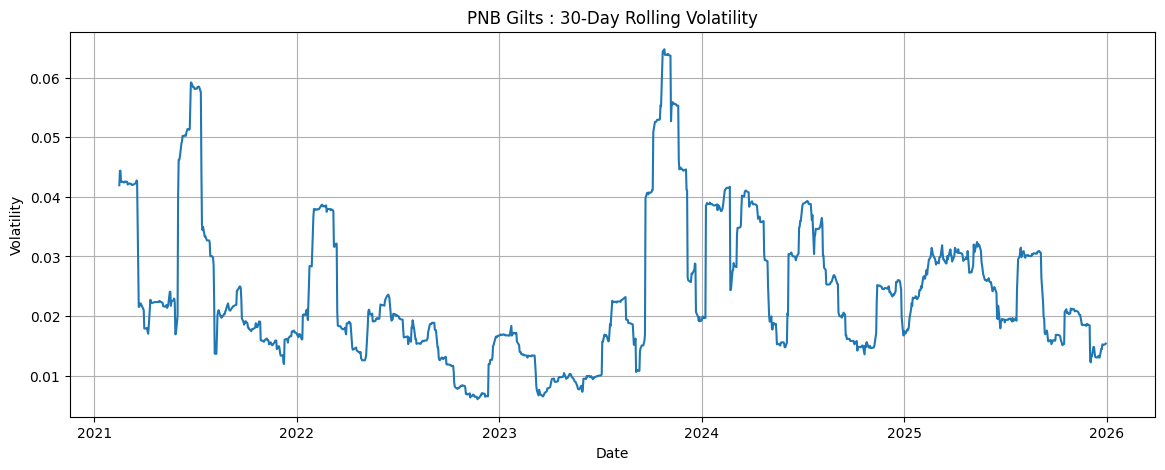

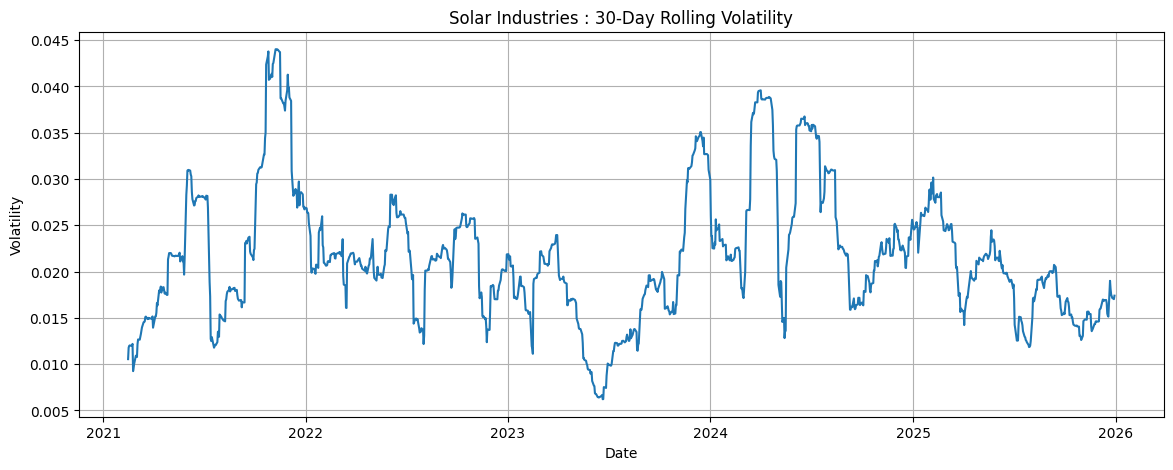

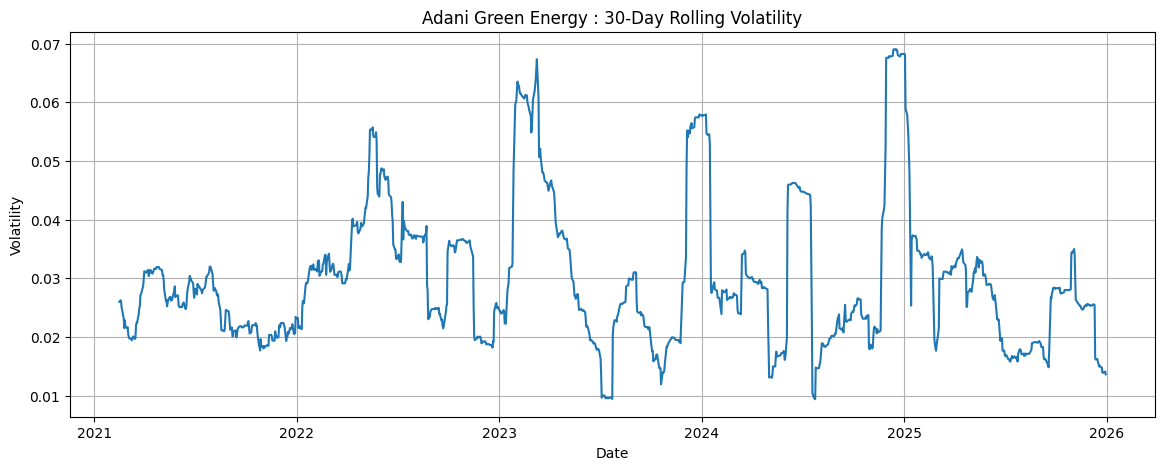

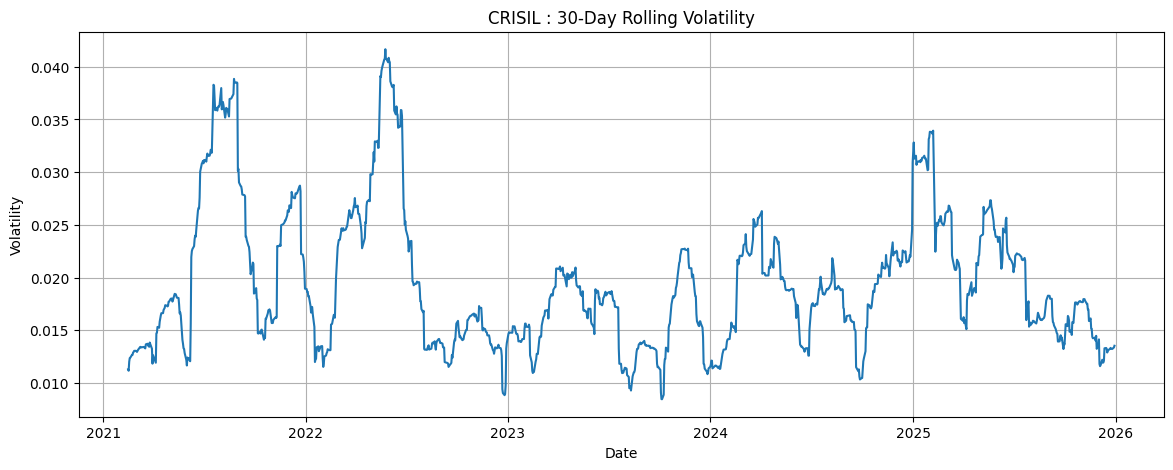

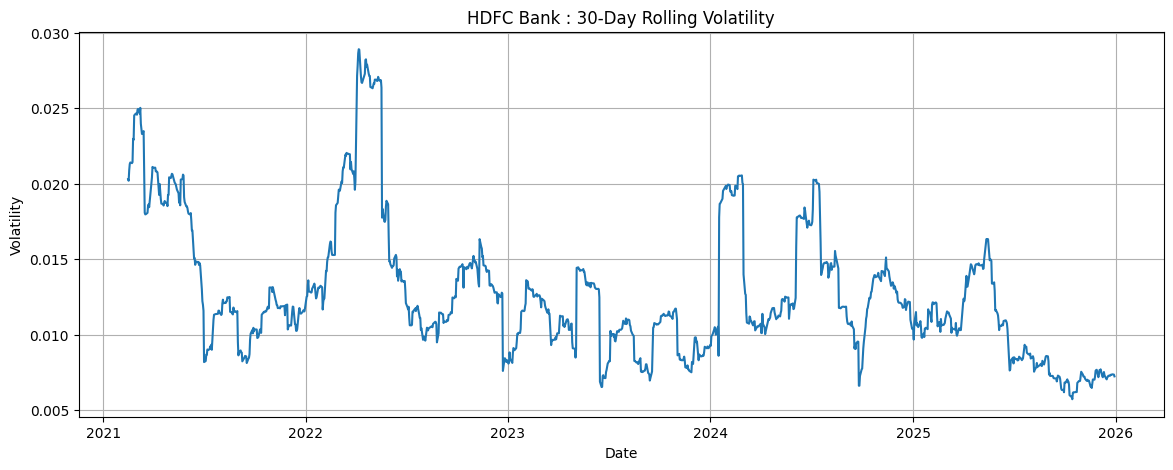

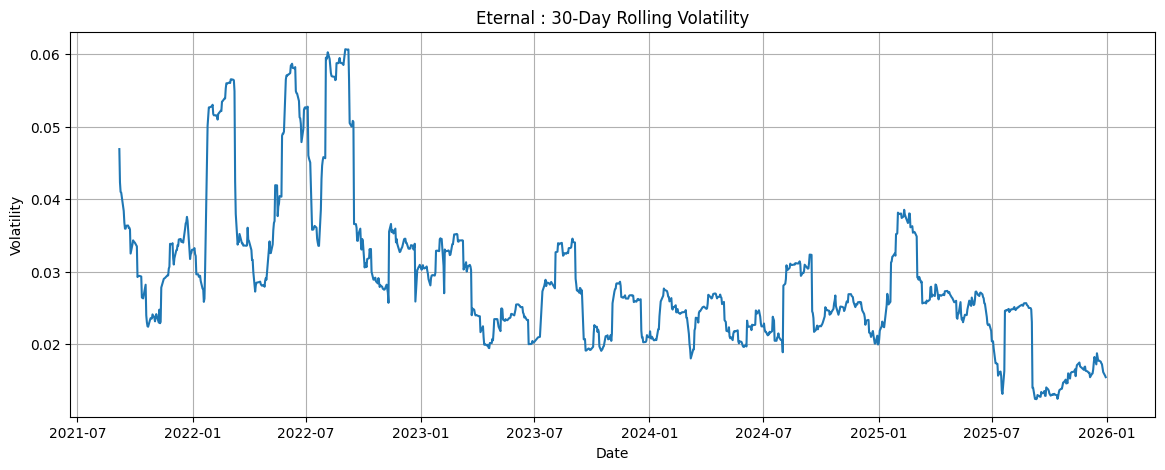

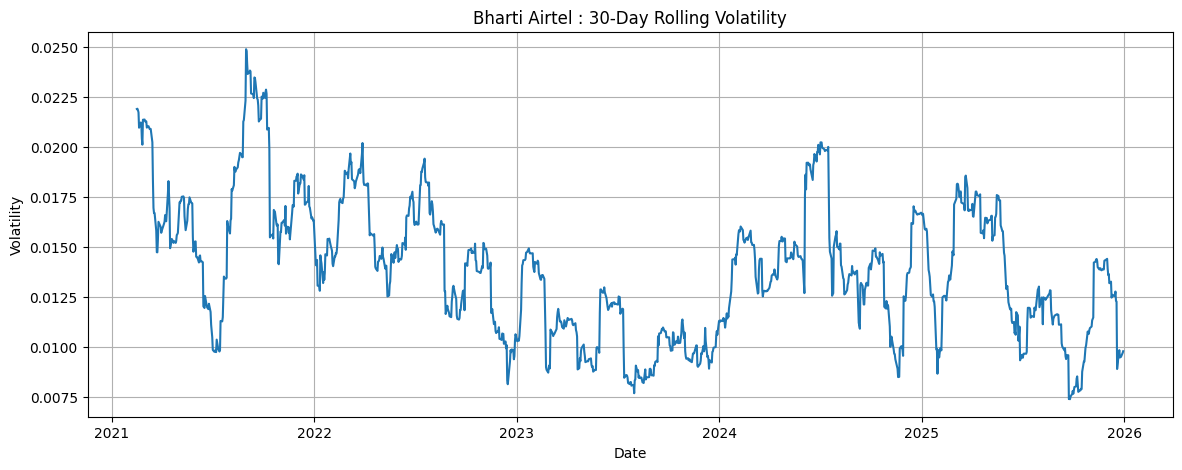

In [ ]:
for stock,data in all_data.items():

    plt.figure(figsize=(14,5))

    plt.plot(
        data.index,
        data['RollingVolatility']
    )

    plt.title(
        f"{stock} : 30-Day Rolling Volatility"
    )

    plt.xlabel("Date")

    plt.ylabel("Volatility")

    plt.grid()

    plt.show()

Volatility Ranking Table

In [ ]:
volatility_summary=[]

for stock,data in all_data.items():

    avg_vol=data['RollingVolatility'].mean()

    volatility_summary.append(
        [stock,avg_vol]
    )

volatility_df=pd.DataFrame(
    volatility_summary,
    columns=['Stock',
             'Average Volatility']
)

volatility_df=(
    volatility_df
    .sort_values(
        by='Average Volatility',
        ascending=False
    )
)

volatility_df

,Stock,Average Volatility
2,Adani Green Energy,0.029828
5,Eternal,0.028968
0,PNB Gilts,0.023589
1,Solar Industries,0.021513
3,CRISIL,0.019483
6,Bharti Airtel,0.013873
4,HDFC Bank,0.012687


Volatility Bar Chart

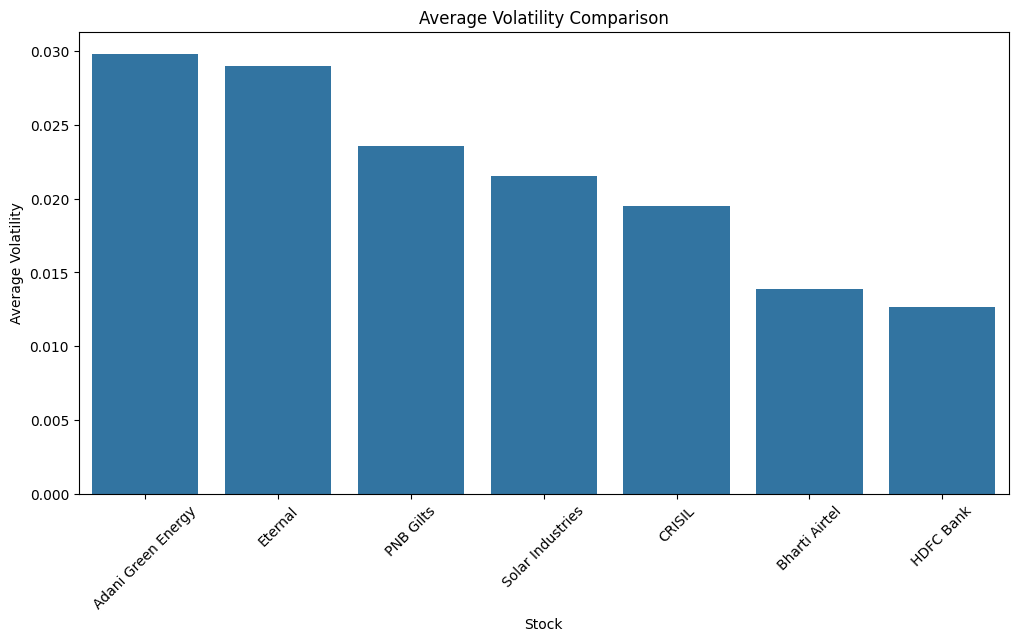

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=volatility_df,

    x='Stock',

    y='Average Volatility'
)

plt.xticks(rotation=45)

plt.title(
    "Average Volatility Comparison"
)

plt.show()

Seasonal Decomposition (252 trading days as approx 1 year)

PNB Gilts


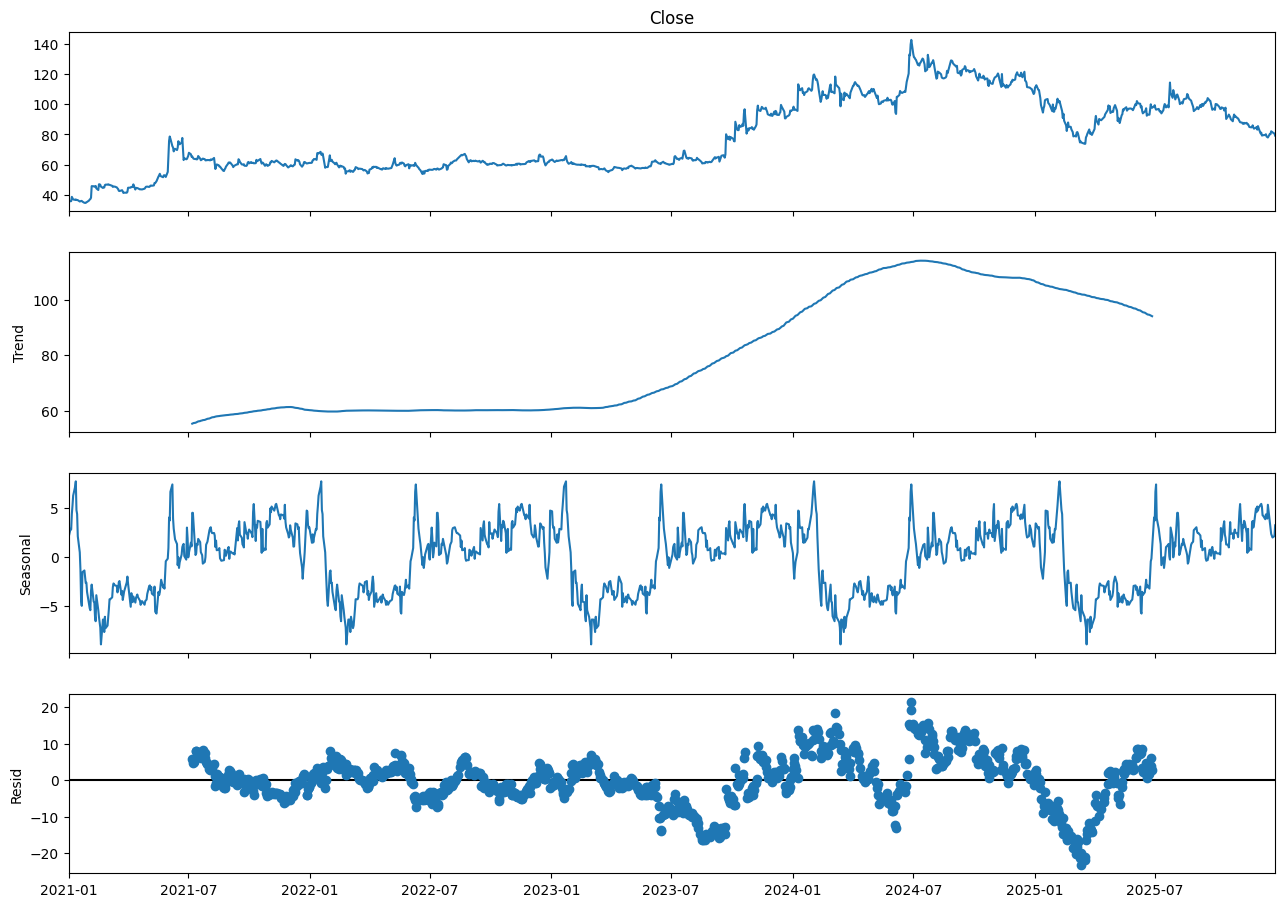

Solar Industries


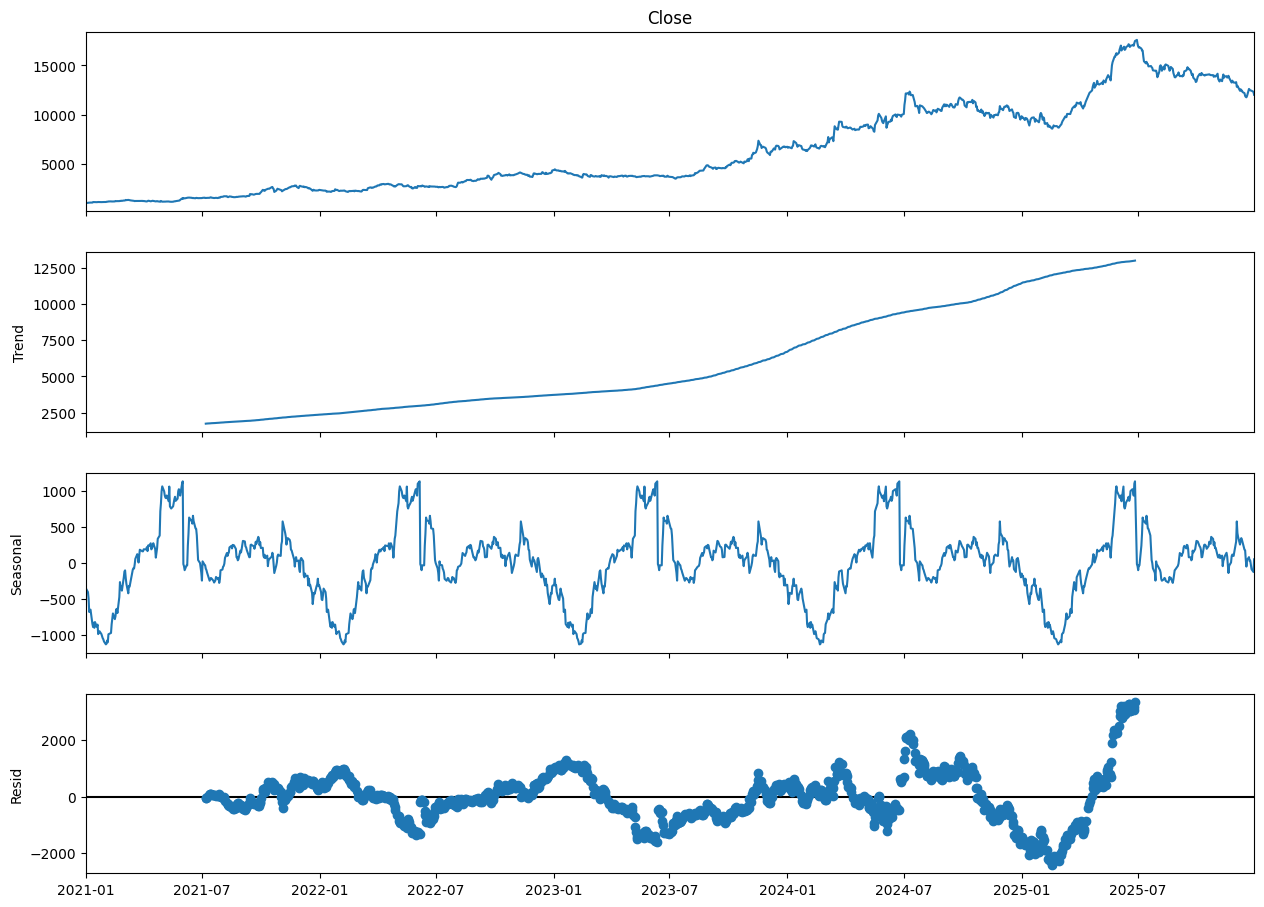

Adani Green Energy


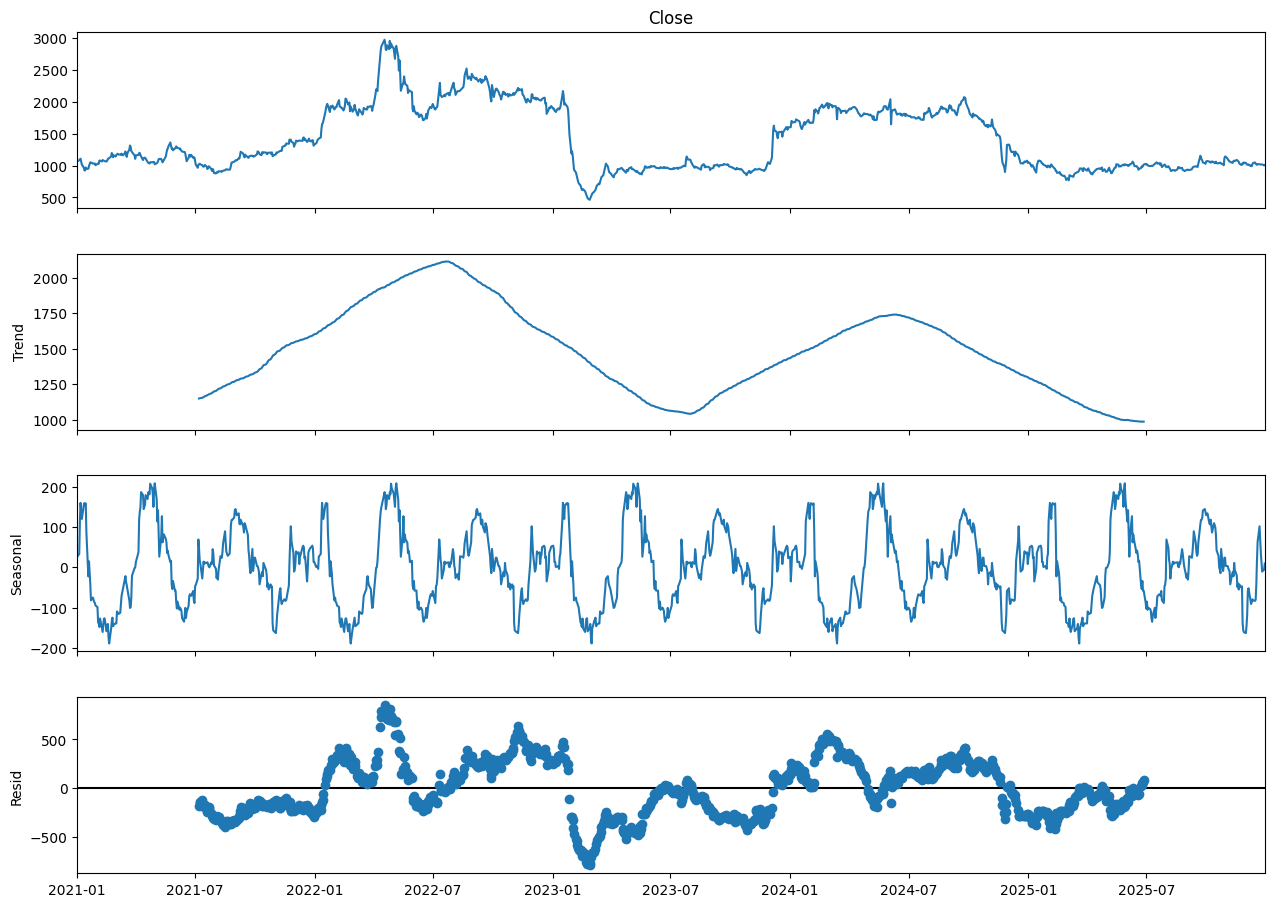

CRISIL


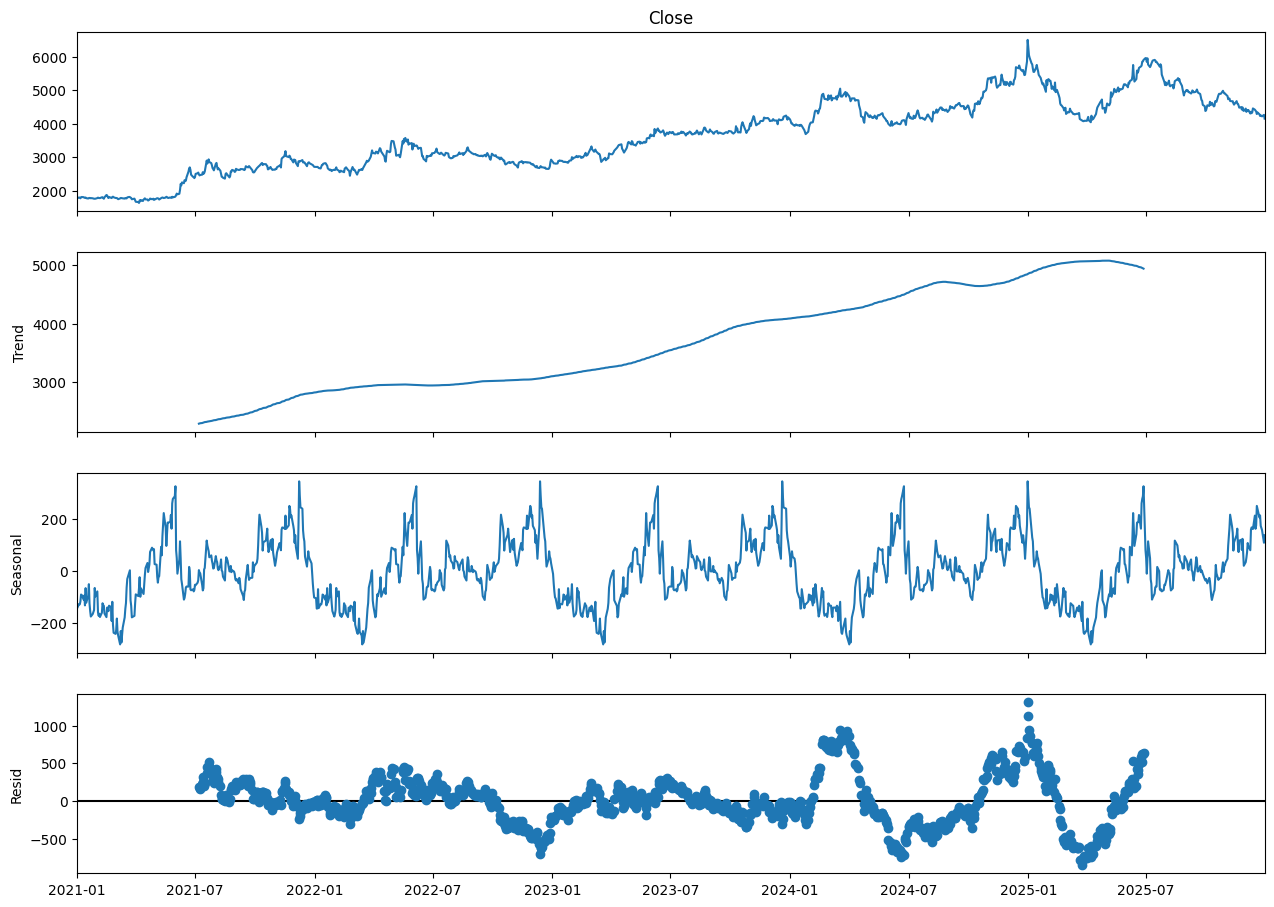

HDFC Bank


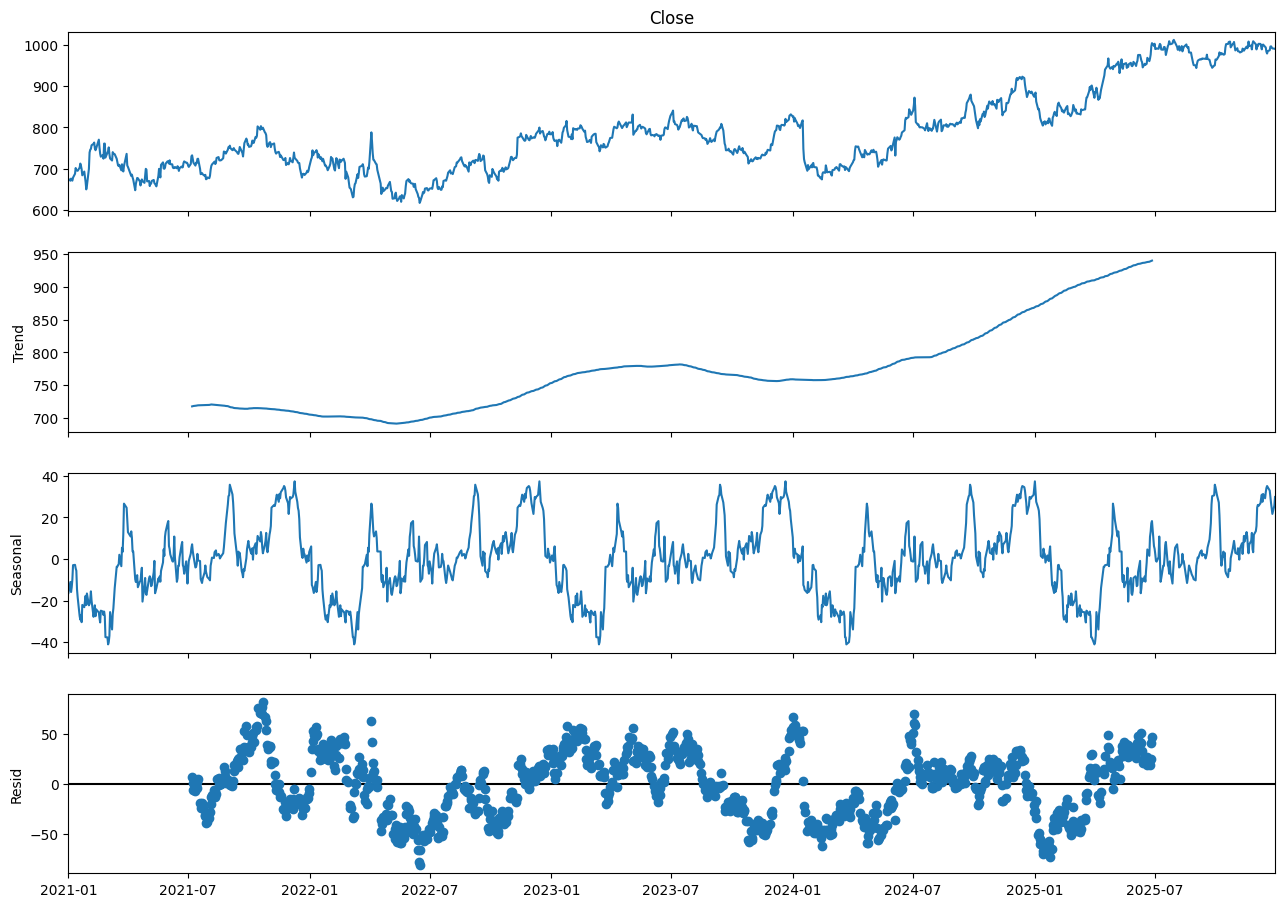

Eternal


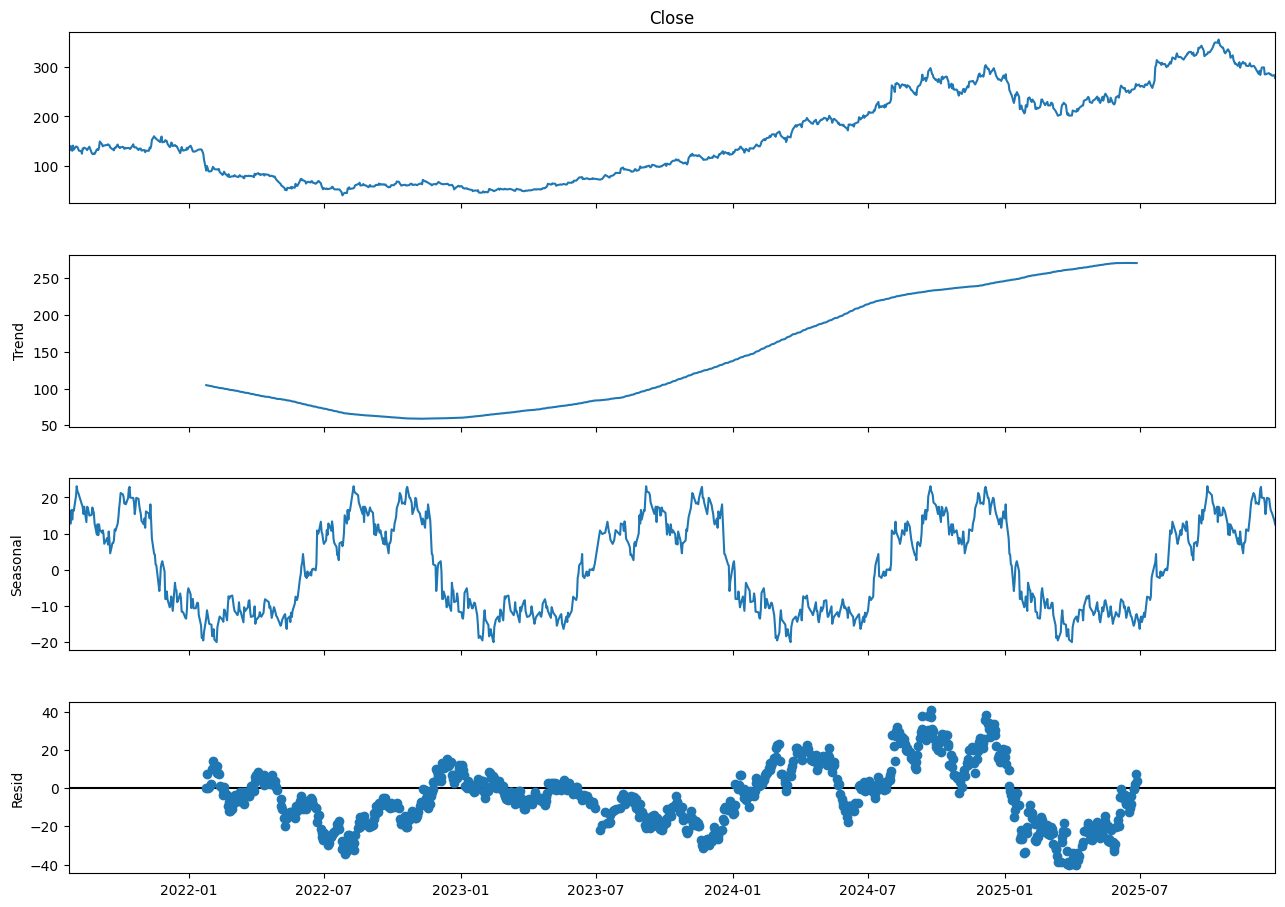

Bharti Airtel


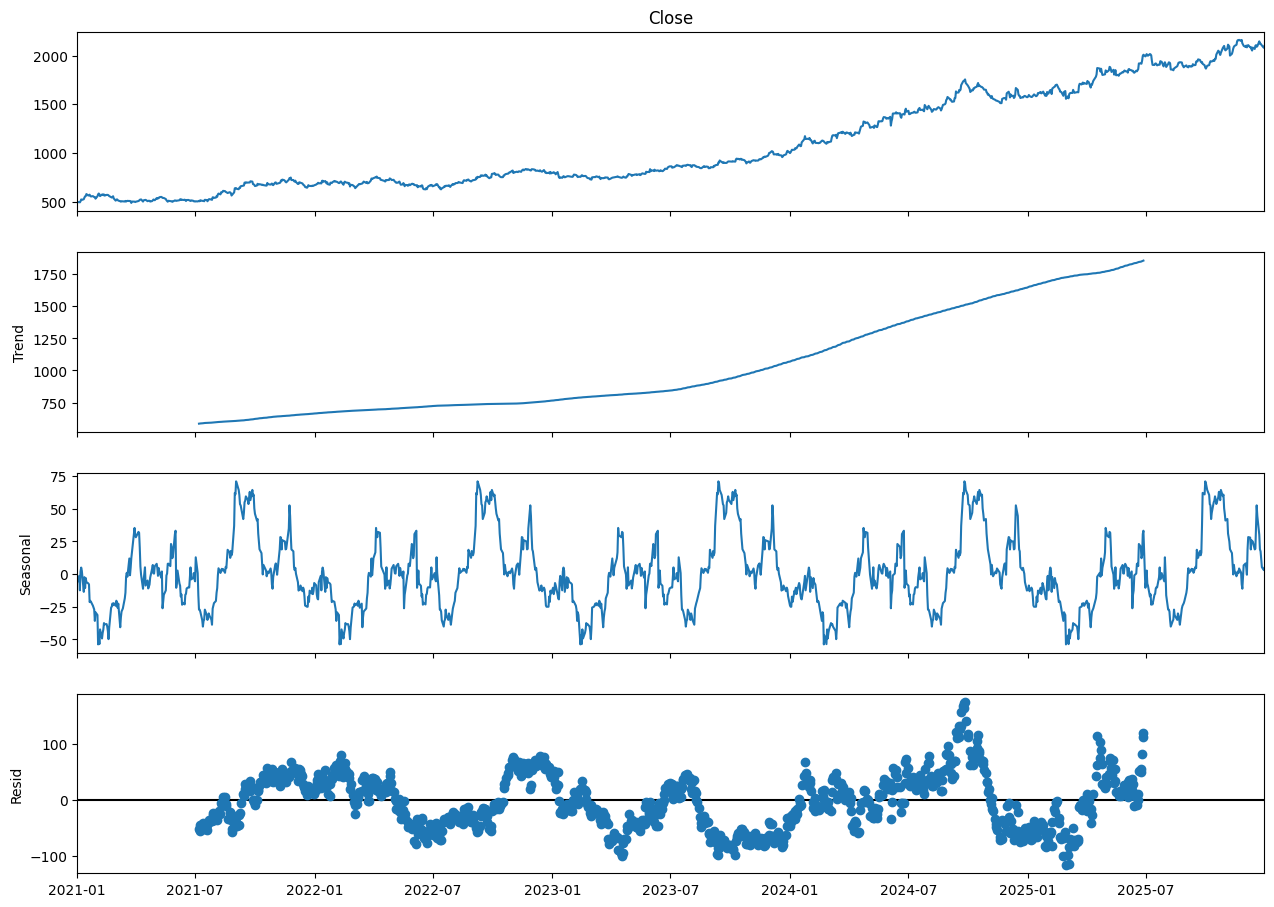

In [ ]:
for stock,data in all_data.items():

    print("="*50)

    print(stock)

    decomposition=seasonal_decompose(
        data['Close'],
        model='additive',
        period=252
    )

    fig=decomposition.plot()

    fig.set_size_inches(
        14,
        10
    )

    plt.show()

Trend Classification

In [ ]:
trend_summary=[]

for stock,data in all_data.items():

    try:

        # remove null values
        close_prices = data['Close'].dropna()

        # ensure enough rows exist
        if len(close_prices) < 2:

            trend_summary.append(
                [stock,
                 np.nan,
                 "Insufficient Data"]
            )

            continue

        start = close_prices.iloc[0]

        end = close_prices.iloc[-1]

        growth=((end-start)/start)*100

        if growth > 50:

            trend="Strong Uptrend"

        elif growth > 10:

            trend="Moderate Uptrend"

        elif growth > -10:

            trend="Sideways"

        else:

            trend="Downtrend"

        trend_summary.append(
            [stock,
             round(growth,2),
             trend]
        )

    except Exception as e:

        print(
            f"Error in {stock}: {e}"
        )

        trend_summary.append(
            [stock,
             np.nan,
             "Error"]
        )


trend_df=pd.DataFrame(

    trend_summary,

    columns=[
        'Stock',
        'Growth%',
        'Trend'
    ]
)

trend_df

,Stock,Growth%,Trend
0,PNB Gilts,121.43,Strong Uptrend
1,Solar Industries,1011.26,Strong Uptrend
2,Adani Green Energy,-5.52,Sideways
3,CRISIL,134.57,Strong Uptrend
4,HDFC Bank,46.82,Moderate Uptrend
5,Eternal,119.92,Strong Uptrend
6,Bharti Airtel,324.88,Strong Uptrend


In [ ]:
print(trend_df)

                Stock  Growth%             Trend
0           PNB Gilts   121.43    Strong Uptrend
1    Solar Industries  1011.26    Strong Uptrend
2  Adani Green Energy    -5.52          Sideways
3              CRISIL   134.57    Strong Uptrend
4           HDFC Bank    46.82  Moderate Uptrend
5             Eternal   119.92    Strong Uptrend
6       Bharti Airtel   324.88    Strong Uptrend


Final Findings

In [ ]:
task1 = sector_df.copy()

# Add trend information
task1 = pd.merge(
    task1,
    trend_df,
    on="Stock",
    how="left"
)

# Add volatility information
task1 = pd.merge(
    task1,
    volatility_df,
    on="Stock",
    how="left"
)

# Fill missing values if any
task1 = task1.fillna("Data Not Available")

# Reset index
task1 = task1.reset_index(drop=True)

task1

,Stock,Sector,Growth%,Trend,Average Volatility
0,PNB Gilts,Financial Services,121.43,Strong Uptrend,0.023589
1,Solar Industries,Chemical/Industrial,1011.26,Strong Uptrend,0.021513
2,Adani Green Energy,Power/Energy,-5.52,Sideways,0.029828
3,CRISIL,Ratings/Analytics,134.57,Strong Uptrend,0.019483
4,HDFC Bank,Banking,46.82,Moderate Uptrend,0.012687
5,Eternal,Retail/E-Commerce,119.92,Strong Uptrend,0.028968
6,Bharti Airtel,Telecommunications,324.88,Strong Uptrend,0.013873


Final Findings with Selection Rationale

In [ ]:
reasons={

"PNB Gilts":
"Interest-rate linked diversification exposure",

"Solar Industries":
"Strong momentum and industrial growth profile",

"Adani Green Energy":
"Renewable sector expansion and high growth",

"CRISIL":
"Stable analytics and ratings business",

"HDFC Bank":
"Large-cap benchmark banking stock",

"Eternal":
"Consumer-tech growth exposure",

"Bharti Airtel":
"Telecom growth and digital expansion"

}

task1["Selection Reason"]=(
    task1["Stock"]
    .map(reasons)
)

task1

,Stock,Sector,Growth%,Trend,Average Volatility,Selection Reason
0,PNB Gilts,Financial Services,121.43,Strong Uptrend,0.023589,Interest-rate linked diversification exposure
1,Solar Industries,Chemical/Industrial,1011.26,Strong Uptrend,0.021513,Strong momentum and industrial growth profile
2,Adani Green Energy,Power/Energy,-5.52,Sideways,0.029828,Renewable sector expansion and high growth
3,CRISIL,Ratings/Analytics,134.57,Strong Uptrend,0.019483,Stable analytics and ratings business
4,HDFC Bank,Banking,46.82,Moderate Uptrend,0.012687,Large-cap benchmark banking stock
5,Eternal,Retail/E-Commerce,119.92,Strong Uptrend,0.028968,Consumer-tech growth exposure
6,Bharti Airtel,Telecommunications,324.88,Strong Uptrend,0.013873,Telecom growth and digital expansion


In [ ]:
task1.to_csv(
    "Task1_StockUniverse.csv",
    index=False
)

print(
    "Task 1 saved successfully"
)

Task 1 saved successfully


# Task 2

Importing Required Libraries

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler

Dealing with Possible Missing Data of Rolling Volatility

In [ ]:
for stock,data in all_data.items():

    data['Returns']=(
        data['Close']
        .pct_change()
    )

    data['RollingVolatility']=(
        data['Returns']
        .rolling(window=30)
        .std()
    )

    data.dropna(inplace=True)

In [ ]:
for stock,data in all_data.items():

    print(stock)

    print(
        data['RollingVolatility']
        .isnull()
        .sum()
    )

PNB Gilts
0
Solar Industries
0
Adani Green Energy
0
CRISIL
0
HDFC Bank
0
Eternal
0
Bharti Airtel
0


Inspecting Data

In [ ]:
for stock,data in all_data.items():

    print(stock)

    print(data.head())

    print(data.info())

    print(data.shape)

PNB Gilts
Price           Close       High        Low       Open   Volume   Returns  \
Date                                                                        
2021-02-15  43.298206  44.828951  43.035794  44.391595   691265 -0.024631   
2021-02-16  47.059464  47.934175  43.123263  43.254471  2125070  0.086869   
2021-02-17  47.059464  48.633943  46.141017  47.584292  2221314  0.000000   
2021-02-18  46.709579  47.846703  46.447163  47.540552   635221 -0.007435   
2021-02-19  45.528721  47.234408  44.785218  46.797053   704666 -0.025281   

Price       RollingVolatility  
Date                           
2021-02-15           0.041953  
2021-02-16           0.044392  
2021-02-17           0.044400  
2021-02-18           0.042521  
2021-02-19           0.042602  
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1205 entries, 2021-02-15 to 2025-12-30
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   C

Check Missing Values

In [ ]:
for stock,data in all_data.items():

    print(stock)

    print(data.isnull().sum())

PNB Gilts
Price
Close                0
High                 0
Low                  0
Open                 0
Volume               0
Returns              0
RollingVolatility    0
dtype: int64
Solar Industries
Price
Close                0
High                 0
Low                  0
Open                 0
Volume               0
Returns              0
RollingVolatility    0
dtype: int64
Adani Green Energy
Price
Close                0
High                 0
Low                  0
Open                 0
Volume               0
Returns              0
RollingVolatility    0
dtype: int64
CRISIL
Price
Close                0
High                 0
Low                  0
Open                 0
Volume               0
Returns              0
RollingVolatility    0
dtype: int64
HDFC Bank
Price
Close                0
High                 0
Low                  0
Open                 0
Volume               0
Returns              0
RollingVolatility    0
dtype: int64
Eternal
Price
Close                0


Verifying Data Types as Int or Float only

In [ ]:
for stock,data in all_data.items():

    print(data.dtypes)

Price
Close                float64
High                 float64
Low                  float64
Open                 float64
Volume                 int64
Returns              float64
RollingVolatility    float64
dtype: object
Price
Close                float64
High                 float64
Low                  float64
Open                 float64
Volume                 int64
Returns              float64
RollingVolatility    float64
dtype: object
Price
Close                float64
High                 float64
Low                  float64
Open                 float64
Volume                 int64
Returns              float64
RollingVolatility    float64
dtype: object
Price
Close                float64
High                 float64
Low                  float64
Open                 float64
Volume                 int64
Returns              float64
RollingVolatility    float64
dtype: object
Price
Close                float64
High                 float64
Low                  float64
Open           

Create Daily Returns : Forecasting can use returns and volatility.

In [ ]:
for stock,data in all_data.items():

    data['Returns']=(
            data['Close']
            .pct_change()
    )

Removing NaN Created by Returns so rhe first row becomes empty.

In [ ]:
for stock,data in all_data.items():

    data.dropna(inplace=True)

Plotting Closing Prices before stationarity testing

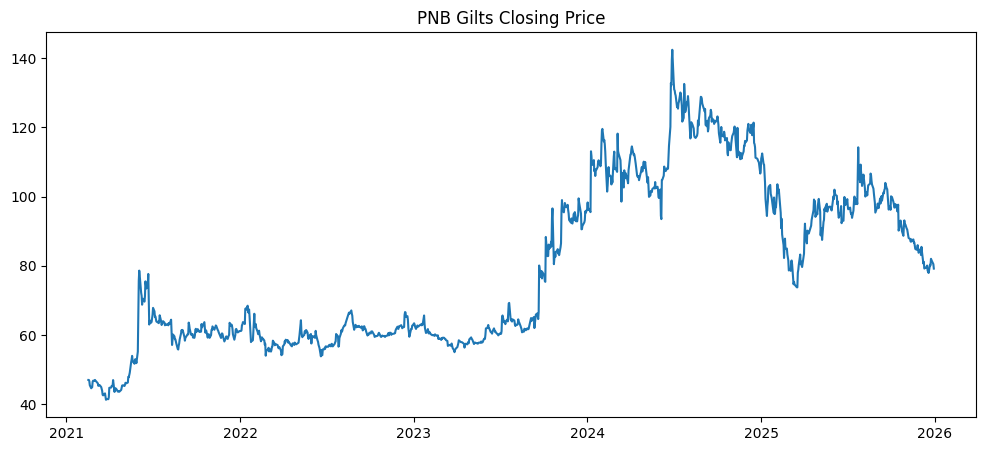

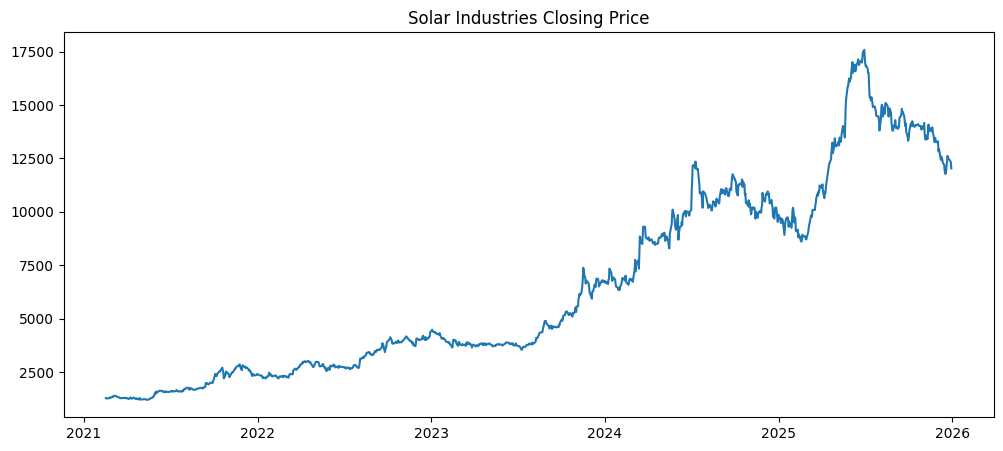

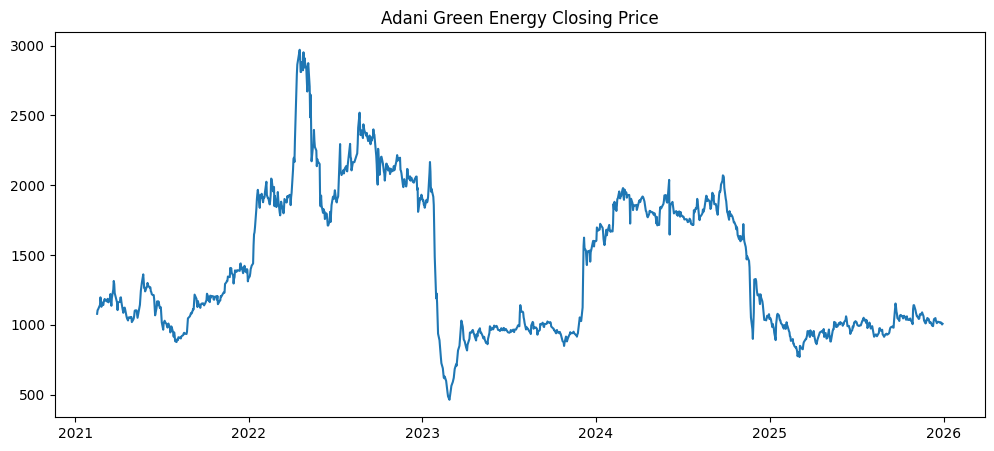

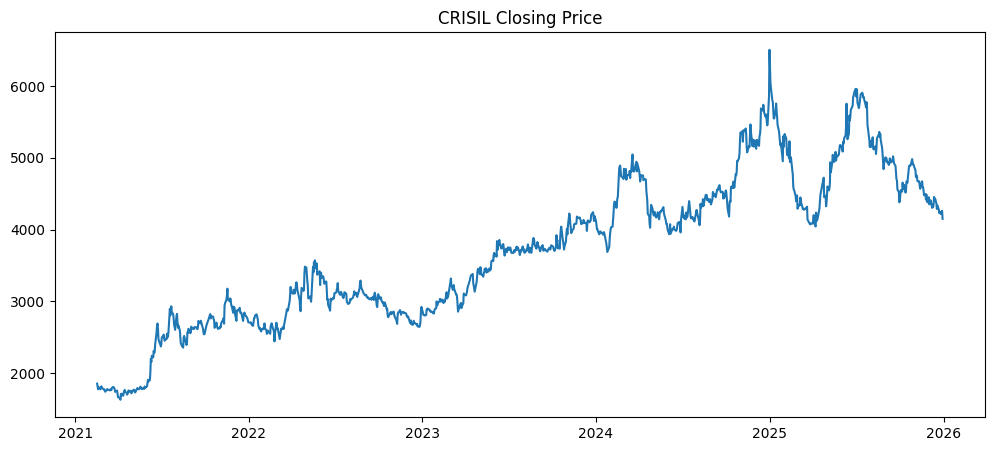

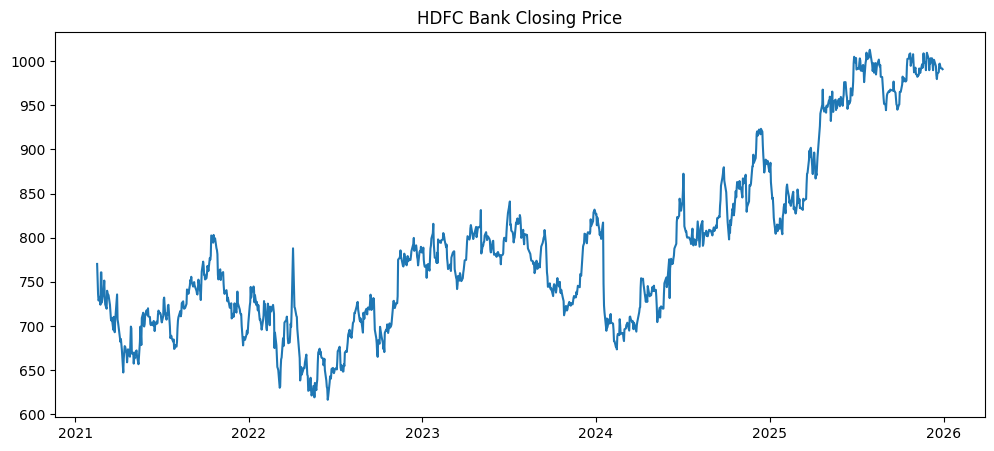

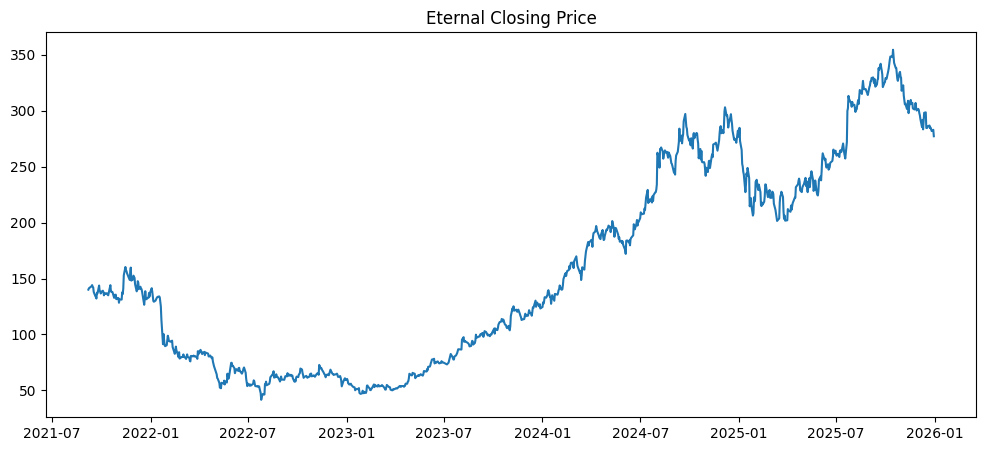

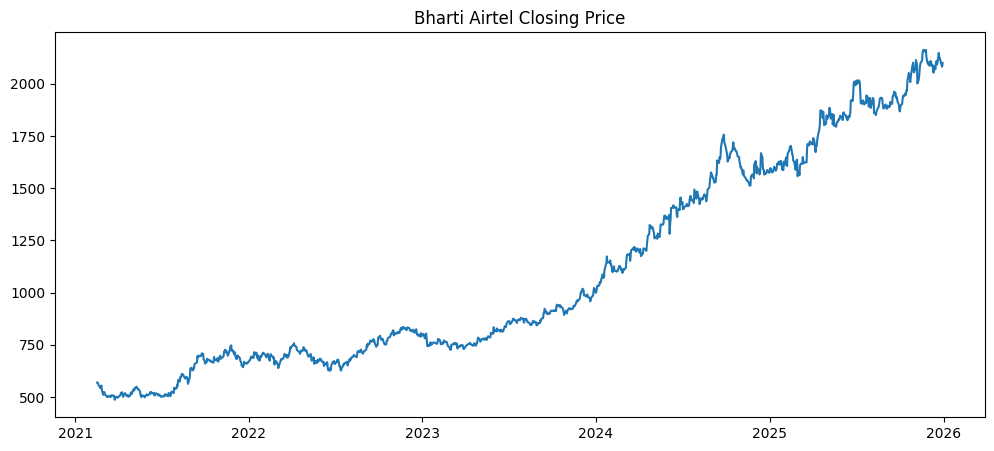

In [ ]:
for stock,data in all_data.items():

    plt.figure(figsize=(12,5))

    plt.plot(
        data.index,
        data['Close']
    )

    plt.title(
        stock+" Closing Price"
    )

    plt.show()

Performing Stationarity Testing where ARIMA assumes stationarity

In [ ]:
for stock,data in all_data.items():

    result=adfuller(
            data['Close']
    )

    print(stock)

    print("ADF:",result[0])

    print("pvalue:",result[1])

PNB Gilts
ADF: -1.6233027413869752
pvalue: 0.47099822557520854
Solar Industries
ADF: -0.6589865822393663
pvalue: 0.8570889190737874
Adani Green Energy
ADF: -2.2519728261089456
pvalue: 0.187925575909068
CRISIL
ADF: -1.9470952884356145
pvalue: 0.310240394384905
HDFC Bank
ADF: -1.1763634345138694
pvalue: 0.6836800375571503
Eternal
ADF: -0.2765180978178442
pvalue: 0.9287648580759912
Bharti Airtel
ADF: 1.2993450460603189
pvalue: 0.9966052662916719


ADF logic :
Since All p>0.05 , So All are Non-Stationary pre-differencing

In [ ]:
for stock,data in all_data.items():

    data['Diff']=(
        data['Close']
        .diff()
    )

    data.dropna(inplace=True)

Differencing transformed non-stationary stock prices into stationary series suitable for ARIMA modeling

In [ ]:
for stock,data in all_data.items():

    print("="*50)
    print(stock)

    original=adfuller(
        data['Close']
    )

    print(
        "Original p-value:",
        original[1]
    )

    data['Diff']=(
        data['Close']
        .diff()
    )

    data.dropna(inplace=True)

    diff=adfuller(
        data['Diff']
    )

    print(
        "Differenced p-value:",
        diff[1]
    )

    if diff[1] < 0.05:
        print(
            "Stationary after differencing"
        )
    else:
        print(
            "Need second differencing"
        )

PNB Gilts
Original p-value: 0.47245615416818726
Differenced p-value: 3.2983482083362684e-28
Stationary after differencing
Solar Industries
Original p-value: 0.8565048769423947
Differenced p-value: 0.0
Stationary after differencing
Adani Green Energy
Original p-value: 0.1848846022885952
Differenced p-value: 9.843781565124363e-12
Stationary after differencing
CRISIL
Original p-value: 0.30729557436741783
Differenced p-value: 2.581208748740538e-10
Stationary after differencing
HDFC Bank
Original p-value: 0.6715785668347738
Differenced p-value: 2.1048644109537705e-25
Stationary after differencing
Eternal
Original p-value: 0.9290564128907027
Differenced p-value: 0.0
Stationary after differencing
Bharti Airtel
Original p-value: 0.996549311035425
Differenced p-value: 3.227749239425207e-17
Stationary after differencing


Scaling

In [ ]:
scaler=MinMaxScaler()

for stock,data in all_data.items():

    data['Scaled_Close']=(
        scaler.fit_transform(
            data[['Close']]
        )
    )

Train/Test Split of data where :
Train = Jan 2021–Jun 2025
& Test = Jul 2025–Dec 2025

In [ ]:
train={}
test={}

for stock,data in all_data.items():

    train[stock]=data[
        :"2025-06-30"
    ]

    test[stock]=data[
        "2025-07-01":
    ]

In [ ]:
for stock in stocks:

    print(stock)

    print(train[stock].shape)

    print(test[stock].shape)

PNB Gilts
(1077, 9)
(125, 9)
Solar Industries
(1077, 9)
(125, 9)
Adani Green Energy
(1077, 9)
(125, 9)
CRISIL
(1077, 9)
(125, 9)
HDFC Bank
(1077, 9)
(125, 9)
Eternal
(919, 9)
(125, 9)
Bharti Airtel
(1077, 9)
(125, 9)


Export Clean Datasets and Save processed Data

In [ ]:
for stock,data in all_data.items():

    data.to_csv(
        stock+"_cleaned.csv"
    )

# Task 3

Installing Requirements

In [ ]:
pip install statsmodels prophet scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

from prophet import Prophet

from sklearn.metrics import (
        mean_squared_error,
        mean_absolute_percentage_error
)

import warnings

warnings.filterwarnings('ignore')

In [ ]:
data_dict={}

In [ ]:
for stock in stocks:

    data=pd.read_csv(
            stock+"_cleaned.csv",
            index_col=0,
            parse_dates=True
        )

    data_dict[stock]=data

In [ ]:
for stock,data in data_dict.items():

    print(stock)

    print(data.head())

PNB Gilts
                Close       High        Low       Open  Volume   Returns  \
Date                                                                       
2021-02-18  46.709579  47.846703  46.447163  47.540552  635221 -0.007435   
2021-02-19  45.528721  47.234408  44.785218  46.797053  704666 -0.025281   
2021-02-22  44.654011  46.009813  44.435333  45.572457  475122 -0.019212   
2021-02-23  44.916424  45.747400  44.697746  44.960162  351606  0.005877   
2021-02-24  44.960155  45.310038  43.735559  44.916417  350081  0.000974   

            RollingVolatility      Diff  Scaled_Close  
Date                                                   
2021-02-18           0.042521 -0.349884      0.053211  
2021-02-19           0.042602 -1.180859      0.041531  
2021-02-22           0.042503 -0.874710      0.032878  
2021-02-23           0.042426  0.262413      0.035474  
2021-02-24           0.042442  0.043732      0.035907  
Solar Industries
                  Close         High          Lo

In [ ]:
train={}
test={}

In [ ]:
for stock,data in data_dict.items():

    train[stock]=data[:'2025-06-30']

    test[stock]=data['2025-07-01':]

Sample try

In [ ]:
print(train['HDFC Bank'].shape)

print(test['HDFC Bank'].shape)

(1077, 9)
(125, 9)


In [ ]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 22.2 MB/s eta 0:00:00


In [ ]:
from pmdarima import auto_arima

In [ ]:
best_orders={}

Use Auto ARIMA

In [ ]:
for stock,data in train.items():

    model=auto_arima(

        data['Close'],

        seasonal=False,

        trace=False,

        suppress_warnings=True
    )

    best_orders[stock]=model.order

    print(
        stock,
        model.order
    )

PNB Gilts (1, 1, 2)
Solar Industries (5, 2, 0)
Adani Green Energy (0, 1, 1)
CRISIL (0, 1, 0)
HDFC Bank (2, 1, 2)
Eternal (0, 1, 0)
Bharti Airtel (5, 2, 0)


In [ ]:
arima_models={}

In [ ]:
for stock,data in train.items():

    order=best_orders[stock]

    model=ARIMA(
            data['Close'],
            order=order
        )

    fitted=model.fit()

    arima_models[stock]=fitted

In [ ]:
arima_predictions={}

In [ ]:
for stock,model in arima_models.items():

    forecast=model.forecast(
                steps=len(
                    test[stock]
                )
            )

    arima_predictions[
            stock
    ]=forecast

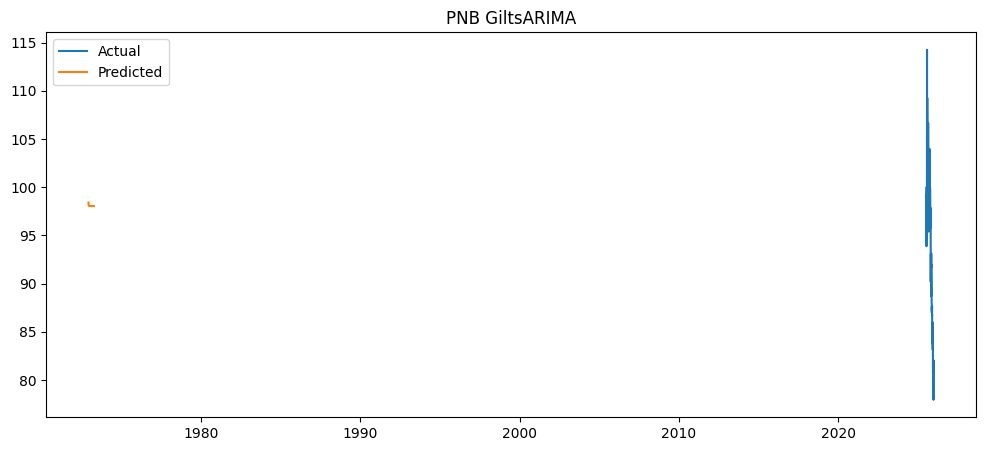

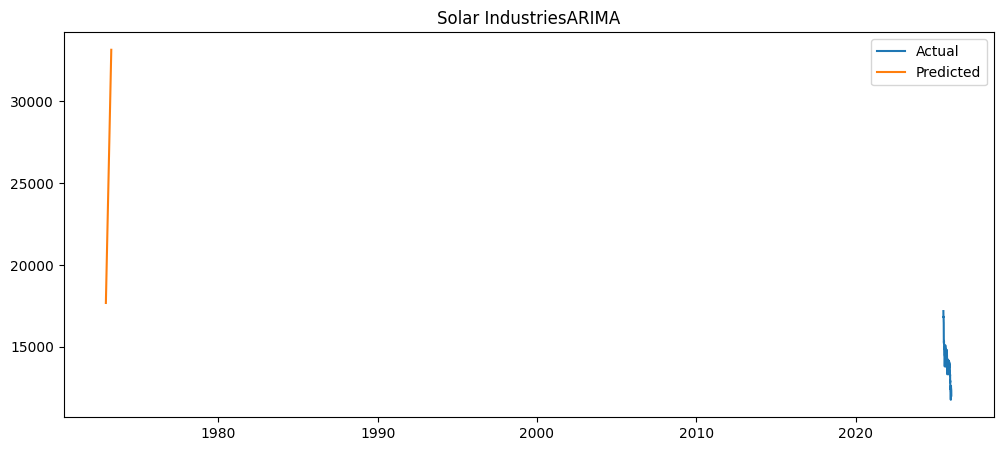

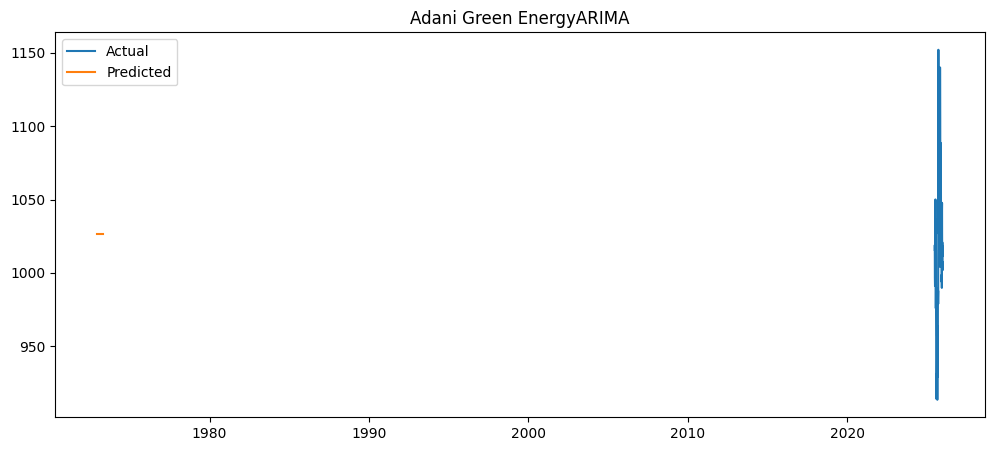

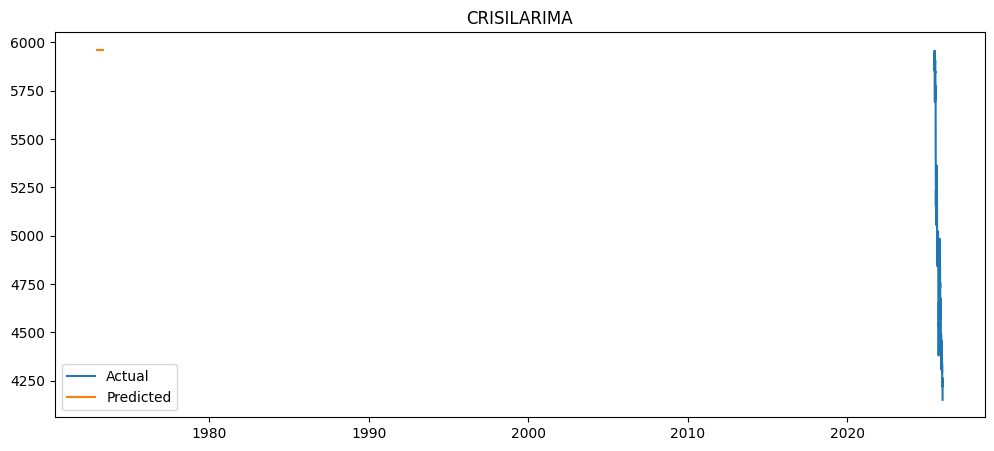

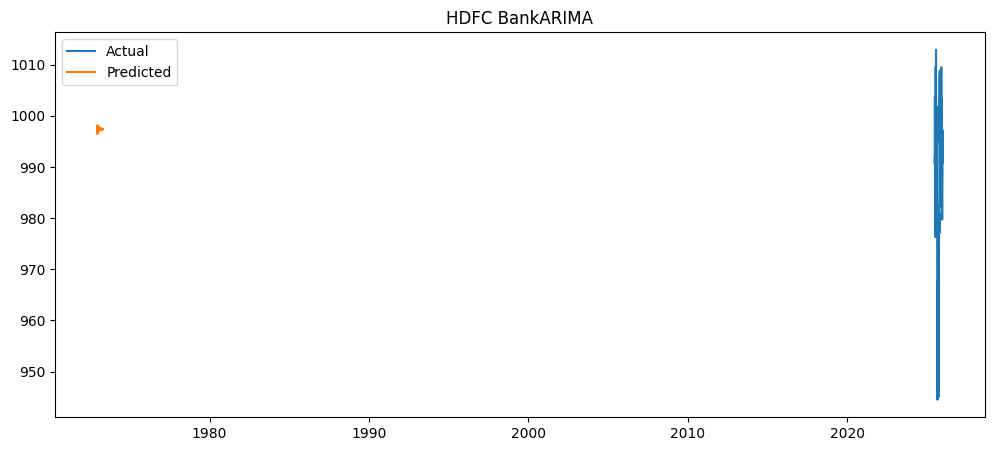

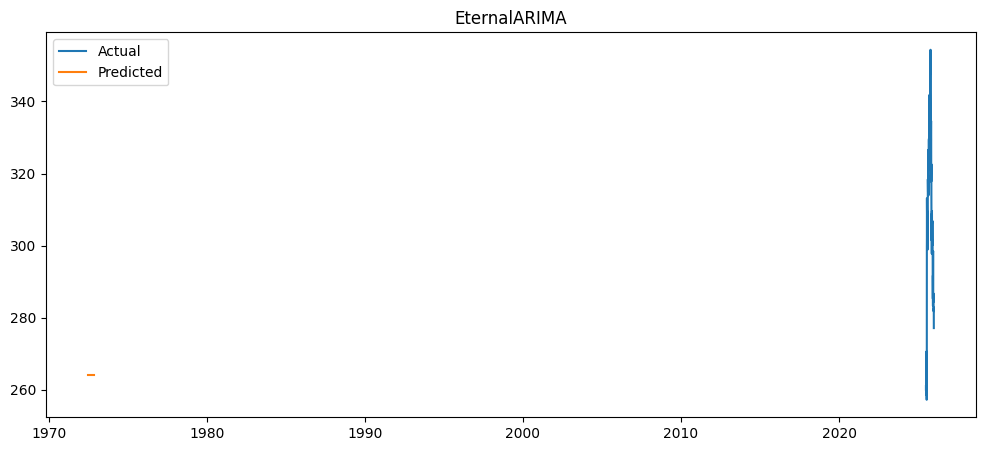

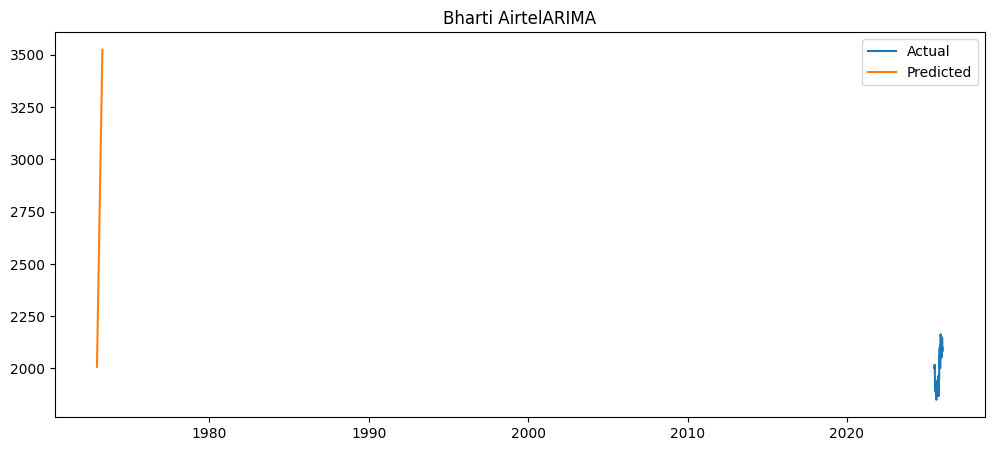

In [ ]:
for stock in stocks:

    plt.figure(
        figsize=(12,5)
    )

    plt.plot(
        test[stock]['Close'],
        label='Actual'
    )

    plt.plot(
        arima_predictions[stock],
        label='Predicted'
    )

    plt.legend()

    plt.title(
        stock+
        "ARIMA"
    )

    plt.show()

In [ ]:
for stock in stocks:

    rmse=np.sqrt(

            mean_squared_error(

            test[stock]['Close'],

            arima_predictions[stock]

        )
    )

    mape=(

        mean_absolute_percentage_error(

        test[stock]['Close'],

        arima_predictions[stock]

        )*100
    )

    print(stock)

    print("RMSE:",rmse)

    print("MAPE:",mape)

PNB Gilts
RMSE: 9.219719657502258
MAPE: 8.007151529095749
Solar Industries
RMSE: 12573.521033678333
MAPE: 83.63241756263837
Adani Green Energy
RMSE: 51.757990898576836
MAPE: 3.990673349147066
CRISIL
RMSE: 1157.5921085638793
MAPE: 22.571527890401896
HDFC Bank
RMSE: 19.546234150904564
MAPE: 1.4420109500152605
Eternal
RMSE: 50.06074458235467
MAPE: 13.95388742792106
Bharti Airtel
RMSE: 864.6512748807583
MAPE: 38.69326768286751


In [ ]:
for stock in stocks:

    actual=np.sign(
        test[stock]['Close']
        .diff()
    )

    predicted=np.sign(
        pd.Series(
        arima_predictions[stock]
        ).diff()
    )

    accuracy=(
        actual.values[1:]
        ==
        predicted.values[1:]
    ).mean()*100

    print(stock)

    print(
        accuracy
    )

PNB Gilts
37.096774193548384
Solar Industries
39.516129032258064
Adani Green Energy
0.0
CRISIL
0.0
HDFC Bank
47.58064516129033
Eternal
0.8064516129032258
Bharti Airtel
50.806451612903224


In [ ]:
future_forecast={}

In [ ]:
for stock,model in arima_models.items():

    forecast=model.forecast(
                    steps=5
                )

    future_forecast[
            stock
    ]=forecast

    print(stock)

    print(forecast)

PNB Gilts
1077    98.410471
1078    98.297418
1079    98.220299
1080    98.167693
1081    98.131808
Name: predicted_mean, dtype: float64
Solar Industries
1077    17680.962473
1078    17774.122050
1079    17894.153639
1080    18048.038972
1081    18181.553927
Name: predicted_mean, dtype: float64
Adani Green Energy
1077    1026.348737
1078    1026.348737
1079    1026.348737
1080    1026.348737
1081    1026.348737
Name: predicted_mean, dtype: float64
CRISIL
1077    5962.169434
1078    5962.169434
1079    5962.169434
1080    5962.169434
1081    5962.169434
Name: predicted_mean, dtype: float64
HDFC Bank
1077    996.549735
1078    997.632595
1079    997.911382
1080    996.546889
1081    997.969987
Name: predicted_mean, dtype: float64
Eternal
919    264.149994
920    264.149994
921    264.149994
922    264.149994
923    264.149994
Name: predicted_mean, dtype: float64
Bharti Airtel
1077    2007.988993
1078    2024.535153
1079    2041.064308
1080    2053.808897
1081    2063.284606
Name: predict

In [ ]:
prophet_data={}

In [ ]:
for stock,data in train.items():

    temp=data.reset_index()

    temp=temp[['Date','Close']]

    temp.columns=[
            'ds',
            'y'
        ]

    prophet_data[
        stock
    ]=temp

In [ ]:
prophet_models={}

In [ ]:
for stock,data in prophet_data.items():

    model=Prophet()

    model.fit(data)

    prophet_models[
            stock
    ]=model

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
prophet_forecast={}

In [ ]:
for stock,model in prophet_models.items():

    future=model.make_future_dataframe(

                periods=len(
                    test[stock]
                )
            )

    forecast=model.predict(
                    future
                )

    prophet_forecast[
        stock
    ]=forecast

In [ ]:
future=model.make_future_dataframe(
            periods=5
        )

forecast=model.predict(
            future
)

# Task 4

In [ ]:
pip install arch statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 24.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL

from arch import arch_model

In [ ]:
for stock in stocks:

    data=pd.read_csv(
        stock+"_cleaned.csv",
        index_col=0,
        parse_dates=True
    )

    data_dict[stock]=data

In [ ]:
print(
data_dict['HDFC Bank'].head()
)

                 Close        High         Low        Open    Volume  \
Date                                                                   
2021-02-18  736.097595  760.558361  733.113969  760.558361  14720560   
2021-02-19  728.898987  740.786029  726.010113  731.693166  17139508   
2021-02-22  733.113892  745.379827  729.064693  731.716831  29451838   
2021-02-23  724.186768  737.707664  721.108447  735.837015  18239906   
2021-02-24  760.795166  764.347075  718.077566  722.931841  14314332   

             Returns  RollingVolatility       Diff  Scaled_Close  
Date                                                              
2021-02-18 -0.020296           0.021307 -15.249512      0.301674  
2021-02-19 -0.009779           0.021411  -7.198608      0.283513  
2021-02-22  0.005783           0.021366   4.214905      0.294146  
2021-02-23 -0.012177           0.021432  -8.927124      0.271625  
2021-02-24  0.050551           0.022979  36.608398      0.363982  


In [ ]:
for stock,data in data_dict.items():

    data['Log_Returns']=np.log(

        data['Close']

        /

        data['Close'].shift(1)

    )

    data.dropna(inplace=True)

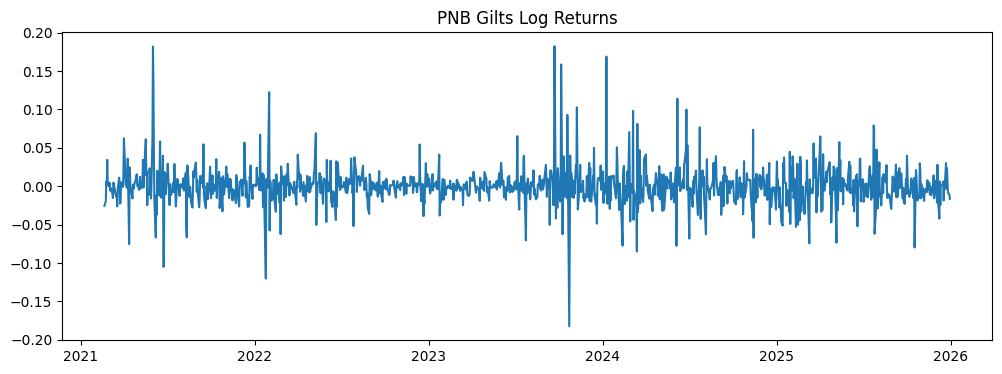

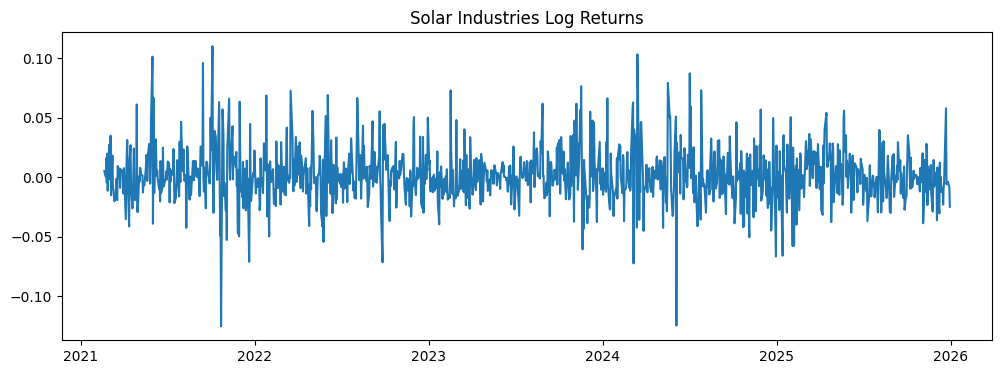

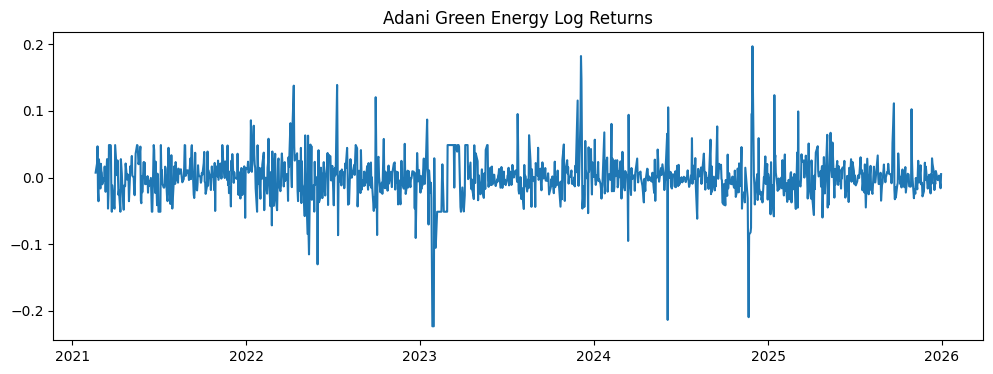

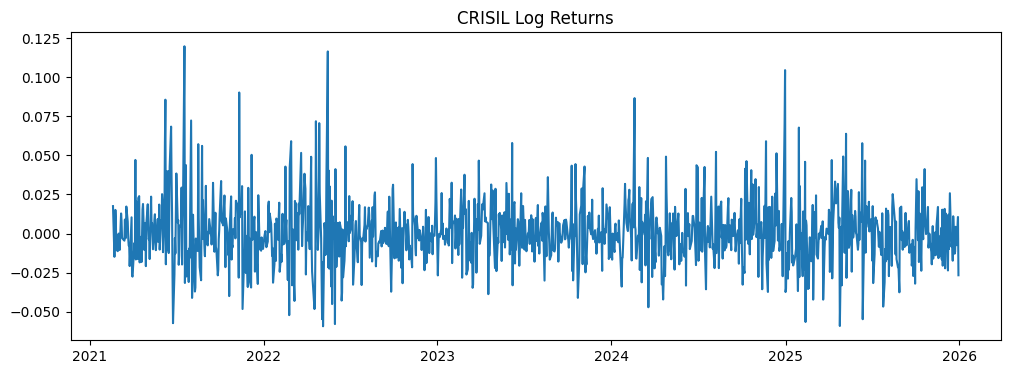

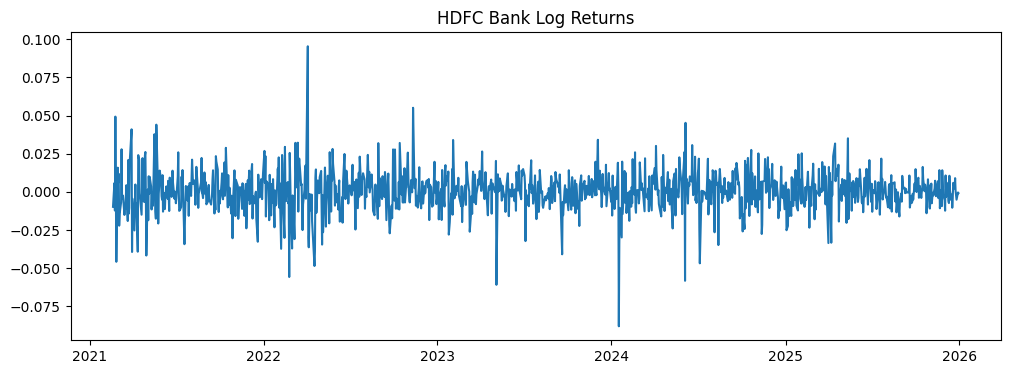

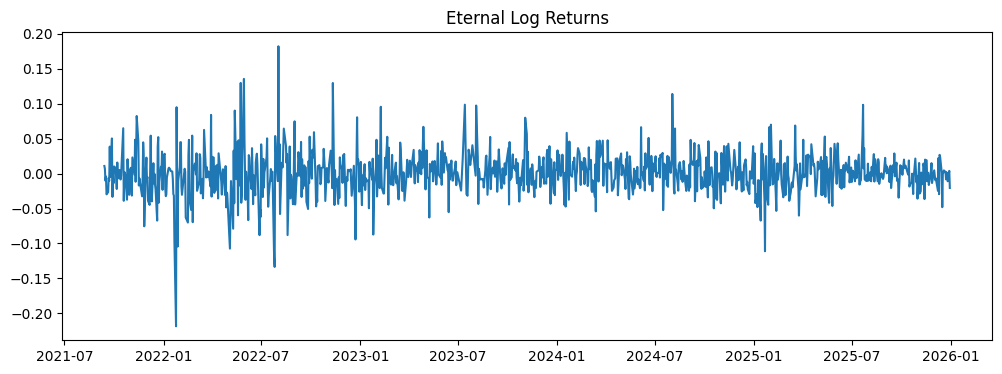

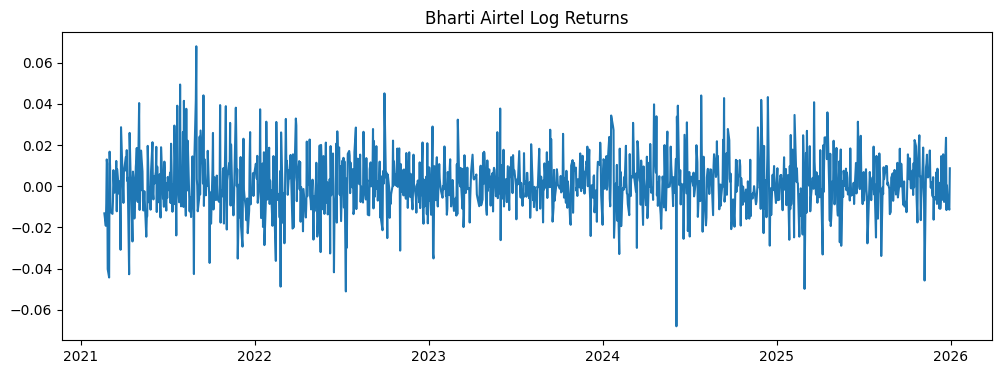

In [ ]:
for stock,data in data_dict.items():

    plt.figure(
        figsize=(12,4)
    )

    plt.plot(
        data.index,
        data['Log_Returns']
    )

    plt.title(
        stock+" Log Returns"
    )

    plt.show()

In [ ]:
for stock,data in data_dict.items():

    data['RollingVol']=(
        data[
        'Log_Returns'
        ]
        .rolling(30)
        .std()
    )

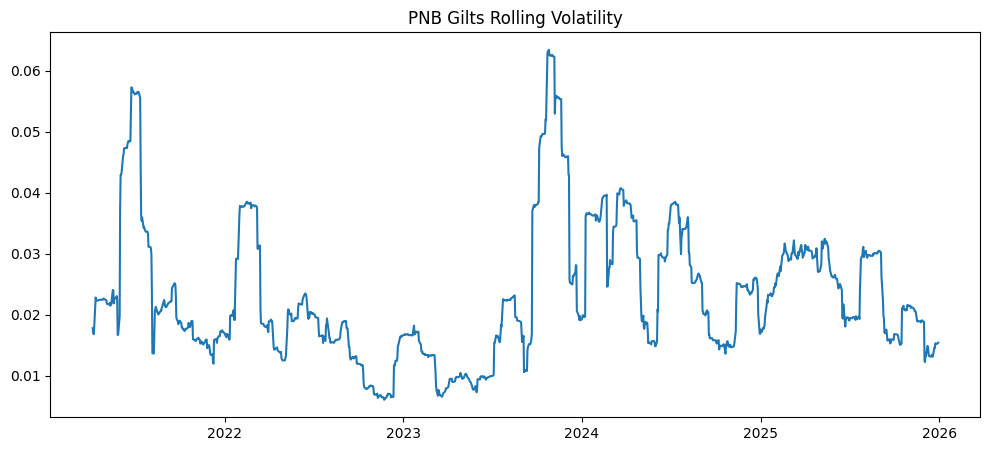

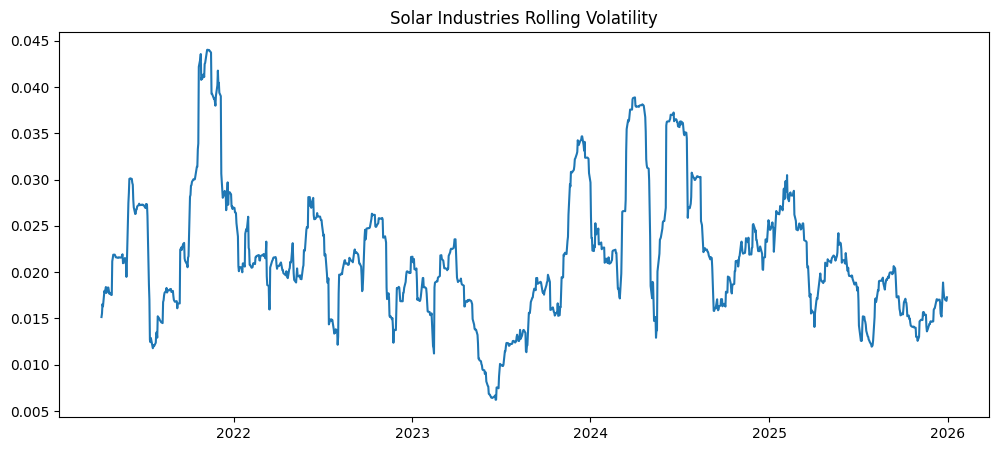

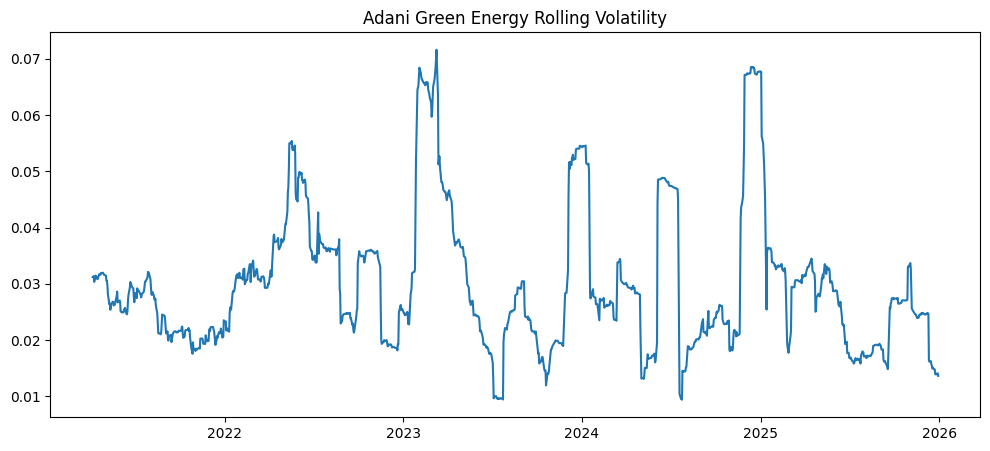

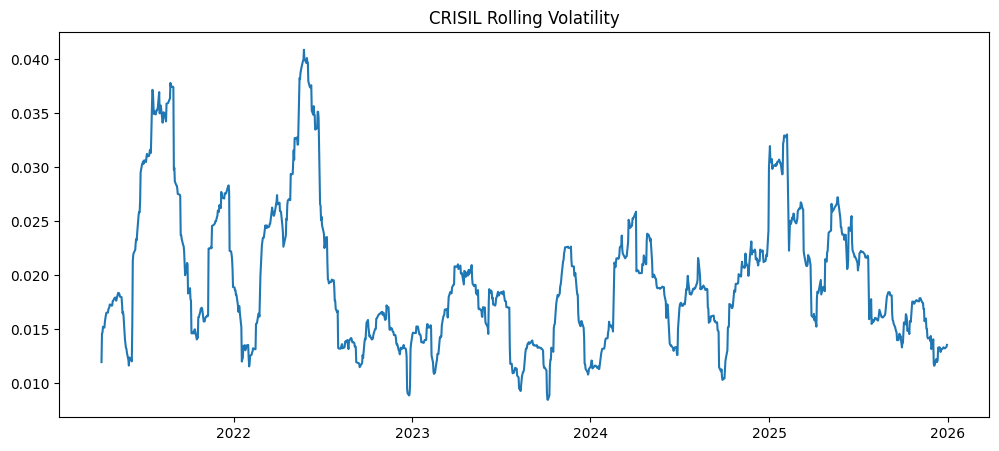

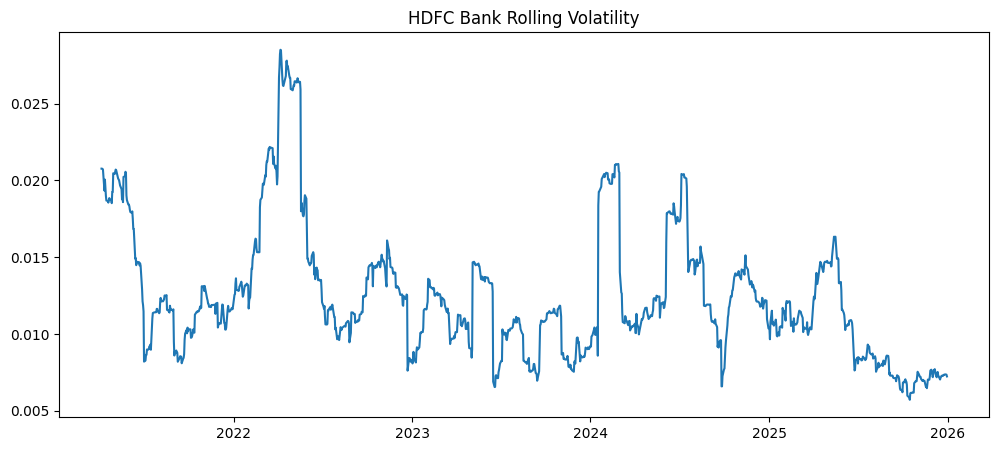

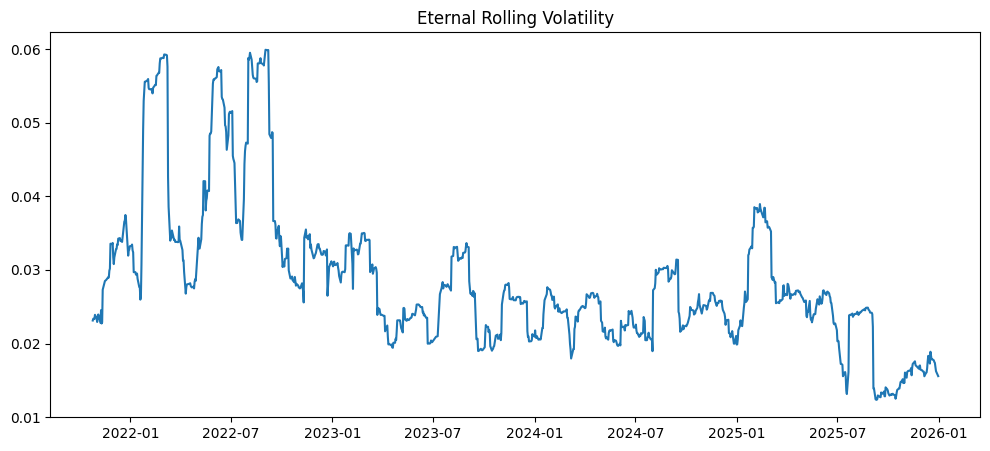

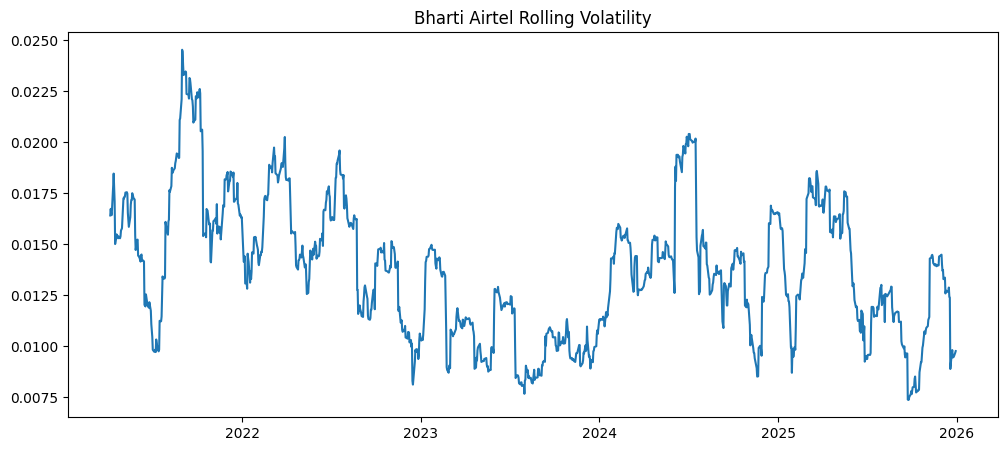

In [ ]:
for stock,data in data_dict.items():

    plt.figure(
        figsize=(12,5)
    )

    plt.plot(
        data.index,
        data['RollingVol']
    )

    plt.title(
        stock+
        " Rolling Volatility"
    )

    plt.show()

In [ ]:
volatility_summary={}

In [ ]:
for stock,data in data_dict.items():

    volatility_summary[
        stock
    ]=(

        data[
        'RollingVol'
        ]
        .mean()

    )

In [ ]:
pd.DataFrame(

volatility_summary.items(),

columns=[
"Stock",
"Avg Volatility"
]

)

,Stock,Avg Volatility
0,PNB Gilts,0.023016
1,Solar Industries,0.021617
2,Adani Green Energy,0.029903
3,CRISIL,0.019513
4,HDFC Bank,0.012444
5,Eternal,0.028725
6,Bharti Airtel,0.013699


In [ ]:
for stock,data in data_dict.items():

    model=arch_model(

            data[
            'Log_Returns'
            ]*100,

            vol='Garch',

            p=1,

            q=1

    )

    result=model.fit()

    print(result.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 6935.162700104563
Iteration:      2,   Func. Count:     14,   Neg. LLF: 3559.2359558515
Iteration:      3,   Func. Count:     21,   Neg. LLF: 2936.9973403294425
Iteration:      4,   Func. Count:     28,   Neg. LLF: 2706.1304379536264
Iteration:      5,   Func. Count:     34,   Neg. LLF: 3114.387547383055
Iteration:      6,   Func. Count:     41,   Neg. LLF: 2703.375119480802
Iteration:      7,   Func. Count:     47,   Neg. LLF: 2702.2481417114386
Iteration:      8,   Func. Count:     52,   Neg. LLF: 2702.245799203913
Iteration:      9,   Func. Count:     57,   Neg. LLF: 2702.2455263370402
Iteration:     10,   Func. Count:     62,   Neg. LLF: 2702.245525124542
Iteration:     11,   Func. Count:     66,   Neg. LLF: 2702.245525124622
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2702.245525124542
            Iterations: 11
            Function evaluations: 66
            Gradient evaluations: 

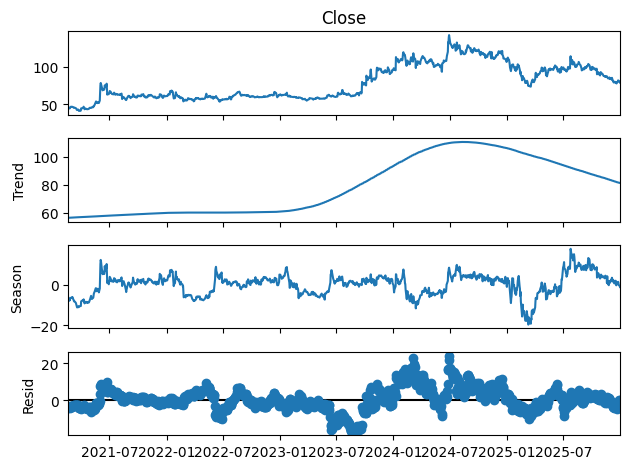

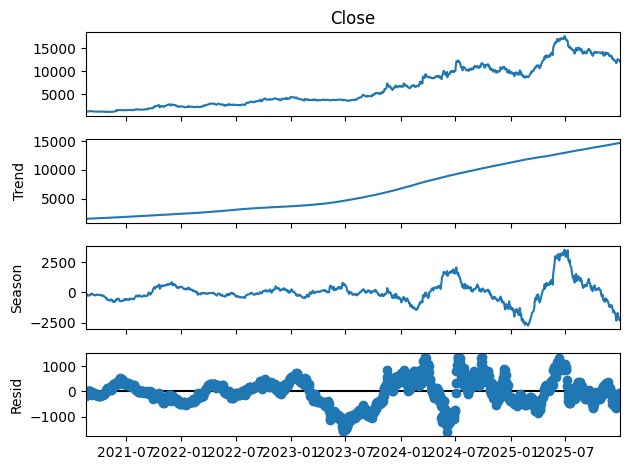

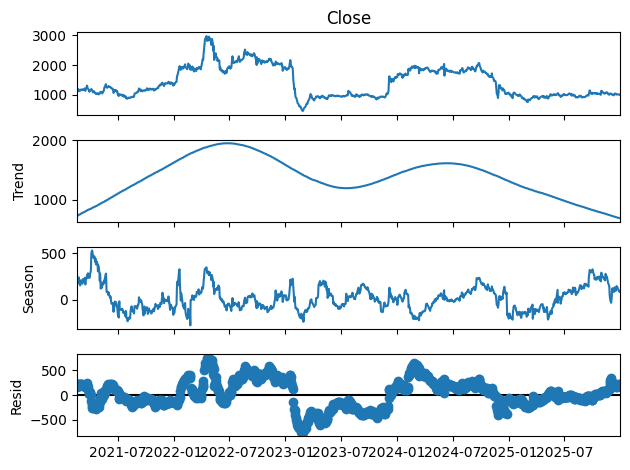

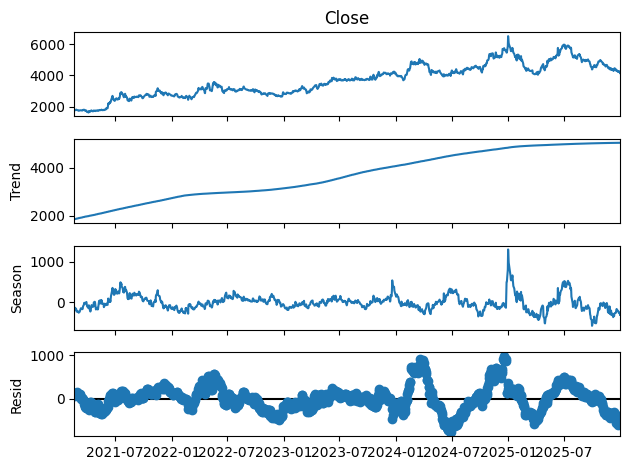

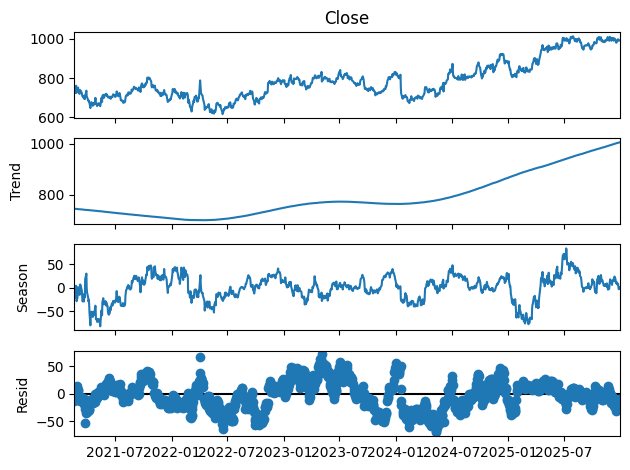

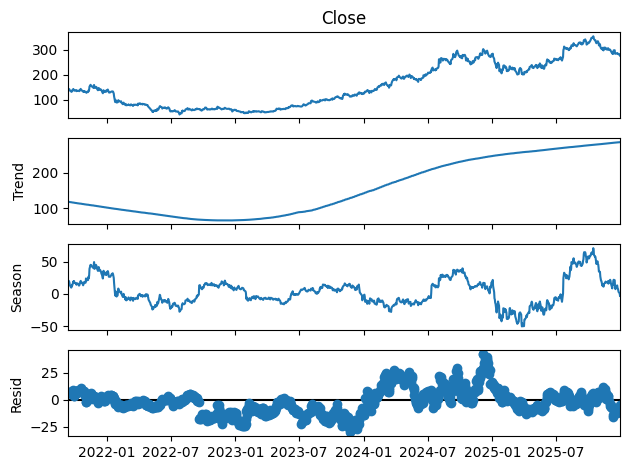

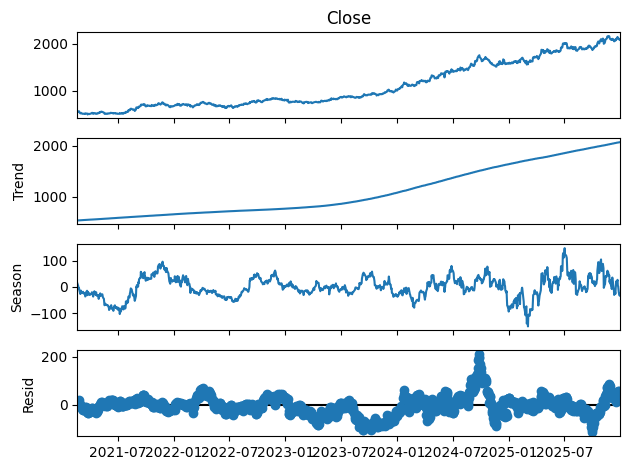

In [ ]:
for stock,data in data_dict.items():

    stl=STL(

        data['Close'],

        period=252

    )

    result=stl.fit()

    result.plot()

    plt.show()

In [ ]:
trend_summary={}

In [ ]:
for stock,data in data_dict.items():

    stl=STL(
            data['Close'],
            period=252
        )

    result=stl.fit()

    trend=result.trend

    slope=trend.iloc[-1]-trend.iloc[0]

    trend_summary[
        stock
    ]=slope

In [ ]:
trend_table=[]

In [ ]:
for stock,slope in trend_summary.items():

    if slope>0:

        status='Upward'

    elif slope<0:

        status='Downward'

    else:

        status='Sideways'

    trend_table.append(
            [
            stock,
            status
            ]
    )

pd.DataFrame(
trend_table,
columns=[
"Stock",
"Trend"
]
)

,Stock,Trend
0,PNB Gilts,Upward
1,Solar Industries,Upward
2,Adani Green Energy,Downward
3,CRISIL,Upward
4,HDFC Bank,Upward
5,Eternal,Upward
6,Bharti Airtel,Upward
